# Soccer Pass Prediction

**Goal:** Given a snapshot of all player and ball positions at the moment of pass initiation, predict which teammate will receive the pass.

**Framing:** Classification — the label is the index of the receiving teammate among all eligible teammates.

**Evaluation Metrics:**
- **Top-1 Accuracy:** % of passes where the predicted receiver matches the actual receiver
- **Top-3 Accuracy:** % of passes where the actual receiver is among the top 3 predicted
- **Average Rank:** Mean rank of the actual receiver in the predicted probability distribution

**Baseline:** Nearest teammate to the ball carrier.

## 1. Data Loading and Processing

In [ ]:
import sys
print(sys.executable)

/usr/bin/python3


In [ ]:
import pandas as pd
import numpy as np
import os
import requests
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

PITCH_LENGTH = 105  # meters
PITCH_WIDTH = 68    # meters
TRACKING_DT = 0.04  # 25 fps

In [ ]:
def download_metrica_data(game_id=1):
    """Download Metrica Sports sample data for a given game."""
    base_url = f"https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_{game_id}/"
    files = [
        f"Sample_Game_{game_id}_RawTrackingData_Home_Team.csv",
        f"Sample_Game_{game_id}_RawTrackingData_Away_Team.csv",
        f"Sample_Game_{game_id}_RawEventsData.csv",
    ]
    for file in files:
        if not os.path.exists(file):
            print(f"Downloading {file}...")
            r = requests.get(base_url + file)
            with open(file, 'wb') as f:
                f.write(r.content)
    print(f"Game {game_id} data ready.")


def load_events(file_path):
    """Load and scale event data to pitch dimensions."""
    events = pd.read_csv(file_path)
    events['Start X'] *= PITCH_LENGTH
    events['Start Y'] *= PITCH_WIDTH
    events['End X'] *= PITCH_LENGTH
    events['End Y'] *= PITCH_WIDTH
    return events


def load_tracking(file_path):
    """Load and clean Metrica tracking data, scaling to pitch dimensions."""
    header_rows = pd.read_csv(file_path, nrows=3, header=None)
    team_name = header_rows.iloc[0, 3]  # 'Home' or 'Away'

    df = pd.read_csv(file_path, skiprows=3, header=None)
    raw_cols = pd.read_csv(file_path, skiprows=2, nrows=0).columns

    new_cols = ['Period', 'Frame', 'Time [s]']
    idx = 3
    while idx < len(df.columns):
        col_label = raw_cols[idx]
        if 'Ball' in col_label:
            new_cols += ['Ball_x', 'Ball_y']
        else:
            new_cols += [f'{team_name}_{col_label}_x', f'{team_name}_{col_label}_y']
        idx += 2

    df.columns = new_cols

    x_cols = [c for c in df.columns if c.endswith('_x')]
    y_cols = [c for c in df.columns if c.endswith('_y')]
    df[x_cols] *= PITCH_LENGTH
    df[y_cols] *= PITCH_WIDTH

    return df, team_name


def compute_velocities(df, dt=TRACKING_DT):
    """Compute smoothed velocities for all players and ball."""
    player_prefixes = [c[:-2] for c in df.columns if c.endswith('_x') and 'Ball' not in c]
    for p in player_prefixes:
        df[f'{p}_vx'] = df[f'{p}_x'].diff() / dt
        df[f'{p}_vy'] = df[f'{p}_y'].diff() / dt
        df[f'{p}_vx'] = df[f'{p}_vx'].rolling(window=5, center=True).mean()
        df[f'{p}_vy'] = df[f'{p}_vy'].rolling(window=5, center=True).mean()

    if 'Ball_x' in df.columns:
        df['Ball_vx'] = df['Ball_x'].diff() / dt
        df['Ball_vy'] = df['Ball_y'].diff() / dt
        df['Ball_vx'] = df['Ball_vx'].rolling(window=5, center=True).mean()
        df['Ball_vy'] = df['Ball_vy'].rolling(window=5, center=True).mean()

    return df

In [ ]:
# Download data for games 1 and 2
for gid in [1, 2]:
    download_metrica_data(gid)

Game 1 data ready.
Game 2 data ready.


## 2. Extract Pass Events as Classification Samples

For each pass, we extract:
- Relative positions and velocities of all teammates (relative to the passer)
- Relative positions and velocities of all opponents (relative to the passer)
- Ball position (same as passer position at pass initiation)
- **Label**: index of the receiving teammate (sorted by player ID)

In [ ]:
def get_player_ids(df, team_name):
    """Extract sorted list of player IDs for a team from tracking data columns."""
    prefix = f"{team_name}_Player"
    ids = set()
    for c in df.columns:
        if c.startswith(prefix) and c.endswith('_x'):
            player_id = c[len(prefix):-2]  # e.g., '11'
            ids.add(player_id)
    return sorted(ids, key=lambda x: int(x))


def extract_pass_samples(events, home_tracking, away_tracking, frame_offset=5):
    """
    Extract classification samples from pass events.

    Returns:
        samples: list of dicts with features and labels
    """
    home_tracking_indexed = home_tracking.set_index('Frame') if home_tracking.index.name != 'Frame' else home_tracking
    away_tracking_indexed = away_tracking.set_index('Frame') if away_tracking.index.name != 'Frame' else away_tracking

    pass_events = events[events['Type'] == 'PASS'].copy()

    home_ids = get_player_ids(home_tracking, 'Home')
    away_ids = get_player_ids(away_tracking, 'Away')

    samples = []

    for _, row in pass_events.iterrows():
        frame = int(row['Start Frame']) - frame_offset
        team = row['Team']
        passer_name = row['From']     # e.g., 'Player11'
        receiver_name = row['To']     # e.g., 'Player1'

        if pd.isna(passer_name) or pd.isna(receiver_name):
            continue
        if frame not in home_tracking_indexed.index:
            continue

        # Determine which team is passing
        if team == 'Home':
            team_prefix = 'Home'
            opp_prefix = 'Away'
            team_ids = home_ids
            opp_ids = away_ids
            team_df = home_tracking_indexed
            opp_df = away_tracking_indexed
        else:
            team_prefix = 'Away'
            opp_prefix = 'Home'
            team_ids = away_ids
            opp_ids = home_ids
            team_df = away_tracking_indexed
            opp_df = home_tracking_indexed

        # Get passer ID (e.g., 'Player11' -> '11')
        passer_id = passer_name.replace('Player', '')
        receiver_id = receiver_name.replace('Player', '')

        if passer_id not in team_ids or receiver_id not in team_ids:
            continue

        # Get passer position
        passer_x_col = f'{team_prefix}_Player{passer_id}_x'
        passer_y_col = f'{team_prefix}_Player{passer_id}_y'

        if passer_x_col not in team_df.columns:
            continue

        passer_x = team_df.loc[frame, passer_x_col]
        passer_y = team_df.loc[frame, passer_y_col]

        if np.isnan(passer_x) or np.isnan(passer_y):
            continue

        # Build list of eligible teammates (excluding passer)
        teammates_on_field = []
        for pid in team_ids:
            if pid == passer_id:
                continue
            x_col = f'{team_prefix}_Player{pid}_x'
            y_col = f'{team_prefix}_Player{pid}_y'
            if x_col not in team_df.columns:
                continue
            px = team_df.loc[frame, x_col]
            py = team_df.loc[frame, y_col]
            if not np.isnan(px) and not np.isnan(py):
                # Get velocity if available
                vx_col = f'{team_prefix}_Player{pid}_vx'
                vy_col = f'{team_prefix}_Player{pid}_vy'
                vx = team_df.loc[frame, vx_col] if vx_col in team_df.columns else 0.0
                vy = team_df.loc[frame, vy_col] if vy_col in team_df.columns else 0.0
                vx = vx if not np.isnan(vx) else 0.0
                vy = vy if not np.isnan(vy) else 0.0
                teammates_on_field.append({
                    'id': pid,
                    'x': px, 'y': py,
                    'vx': vx, 'vy': vy,
                })

        if len(teammates_on_field) == 0:
            continue

        # Find receiver index
        teammate_ids = [t['id'] for t in teammates_on_field]
        if receiver_id not in teammate_ids:
            continue
        receiver_idx = teammate_ids.index(receiver_id)

        # Build opponent positions
        opponents = []
        for pid in opp_ids:
            x_col = f'{opp_prefix}_Player{pid}_x'
            y_col = f'{opp_prefix}_Player{pid}_y'
            if x_col not in opp_df.columns:
                continue
            ox = opp_df.loc[frame, x_col]
            oy = opp_df.loc[frame, y_col]
            if not np.isnan(ox) and not np.isnan(oy):
                vx_col = f'{opp_prefix}_Player{pid}_vx'
                vy_col = f'{opp_prefix}_Player{pid}_vy'
                ovx = opp_df.loc[frame, vx_col] if vx_col in opp_df.columns else 0.0
                ovy = opp_df.loc[frame, vy_col] if vy_col in opp_df.columns else 0.0
                ovx = ovx if not np.isnan(ovx) else 0.0
                ovy = ovy if not np.isnan(ovy) else 0.0
                opponents.append({'x': ox, 'y': oy, 'vx': ovx, 'vy': ovy})

        samples.append({
            'passer_x': passer_x,
            'passer_y': passer_y,
            'teammates': teammates_on_field,
            'opponents': opponents,
            'receiver_idx': receiver_idx,
            'num_teammates': len(teammates_on_field),
            'game_id': None,  # to be set later
        })

    return samples

In [ ]:
def load_game_data(game_id):
    """Load all data for a game and extract pass samples."""
    download_metrica_data(game_id)

    home_tracking, _ = load_tracking(f'Sample_Game_{game_id}_RawTrackingData_Home_Team.csv')
    away_tracking, _ = load_tracking(f'Sample_Game_{game_id}_RawTrackingData_Away_Team.csv')
    home_tracking = compute_velocities(home_tracking)
    away_tracking = compute_velocities(away_tracking)
    events = load_events(f'Sample_Game_{game_id}_RawEventsData.csv')

    samples = extract_pass_samples(events, home_tracking, away_tracking)
    for s in samples:
        s['game_id'] = game_id

    print(f"Game {game_id}: {len(samples)} pass samples extracted")
    return samples


# Load data for both games
all_samples = []
for gid in [1, 2]:
    all_samples.extend(load_game_data(gid))

print(f"\nTotal pass samples: {len(all_samples)}")

# Distribution of number of teammates
num_teammates = [s['num_teammates'] for s in all_samples]
print(f"Teammates per pass: min={min(num_teammates)}, max={max(num_teammates)}, "
      f"mean={np.mean(num_teammates):.1f}, median={np.median(num_teammates):.0f}")

Game 1 data ready.
Game 1: 797 pass samples extracted
Game 2 data ready.
Game 2: 964 pass samples extracted

Total pass samples: 1761
Teammates per pass: min=10, max=10, mean=10.0, median=10


## 2.5 Exploratory Data Analysis

Visualize the pass data before modeling to understand distributions, spatial patterns, and other characteristics.

In [ ]:
# Load raw events for both games to use alongside extracted samples
all_events = pd.concat([
    load_events(f'Sample_Game_{gid}_RawEventsData.csv').assign(game_id=gid)
    for gid in [1, 2]
], ignore_index=True)

pass_events = all_events[all_events['Type'] == 'PASS'].copy()
print(f"Total events: {len(all_events)}")
print(f"Pass events: {len(pass_events)}")
print(f"\nEvent type breakdown:")
print(all_events['Type'].value_counts())

Total events: 3680
Pass events: 1763

Event type breakdown:
Type
PASS              1763
CHALLENGE          544
RECOVERY           526
BALL LOST          490
SET PIECE          157
BALL OUT           100
SHOT                48
FAULT RECEIVED      42
CARD                10
Name: count, dtype: int64


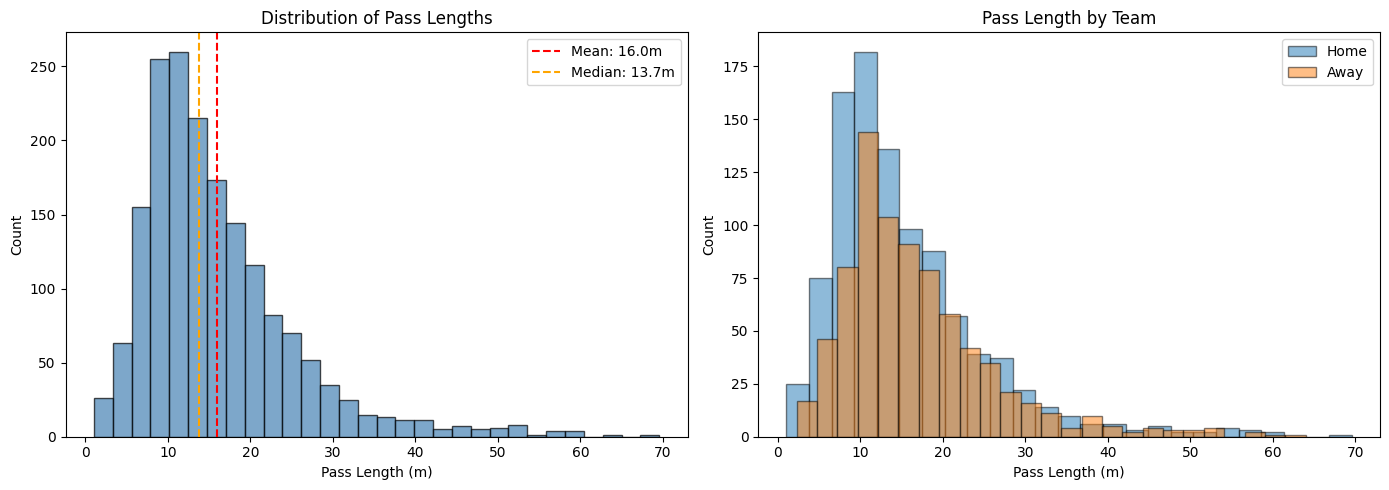

Pass length stats: mean=16.0m, median=13.7m, std=9.3m, max=69.6m


In [ ]:
# --- Pass Length Distribution ---
pass_start = pass_events[['Start X', 'Start Y']].values
pass_end = pass_events[['End X', 'End Y']].values
pass_lengths = np.linalg.norm(pass_end - pass_start, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pass_lengths, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Pass Length (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Pass Lengths')
axes[0].axvline(np.mean(pass_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(pass_lengths):.1f}m')
axes[0].axvline(np.median(pass_lengths), color='orange', linestyle='--', label=f'Median: {np.median(pass_lengths):.1f}m')
axes[0].legend()

# --- Pass Length by Team ---
for team in ['Home', 'Away']:
    team_passes = pass_events[pass_events['Team'] == team]
    start = team_passes[['Start X', 'Start Y']].values
    end = team_passes[['End X', 'End Y']].values
    lengths = np.linalg.norm(end - start, axis=1)
    axes[1].hist(lengths, bins=25, alpha=0.5, label=f'{team}', edgecolor='black')

axes[1].set_xlabel('Pass Length (m)')
axes[1].set_ylabel('Count')
axes[1].set_title('Pass Length by Team')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Pass length stats: mean={np.mean(pass_lengths):.1f}m, "
      f"median={np.median(pass_lengths):.1f}m, "
      f"std={np.std(pass_lengths):.1f}m, "
      f"max={np.max(pass_lengths):.1f}m")

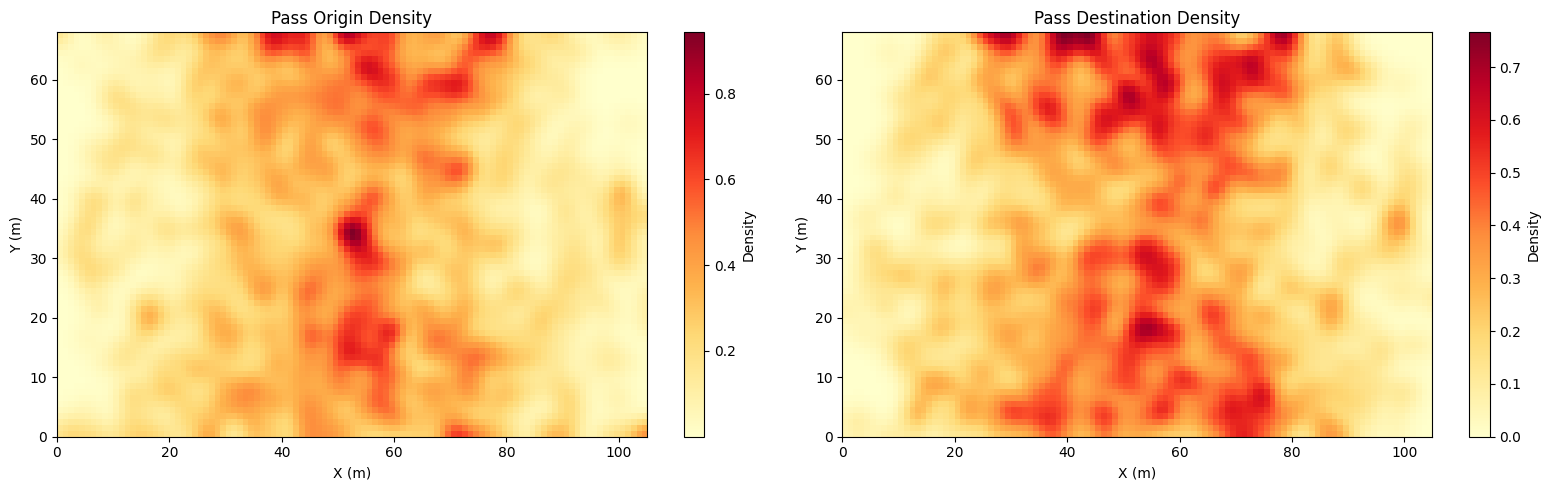

In [ ]:
from scipy.ndimage import gaussian_filter

# --- Pass Origin & Destination Heatmaps ---
H, W = PITCH_WIDTH, PITCH_LENGTH  # 68 x 105

def build_heatmap(x_coords, y_coords, h=H, w=W, sigma=2.0):
    hmap = np.zeros((int(h), int(w)))
    for x, y in zip(x_coords, y_coords):
        gx = int(np.clip(x, 0, w - 1))
        gy = int(np.clip(y, 0, h - 1))
        hmap[gy, gx] += 1
    return gaussian_filter(hmap, sigma=sigma)

origin_heatmap = build_heatmap(pass_events['Start X'], pass_events['Start Y'])
dest_heatmap = build_heatmap(pass_events['End X'], pass_events['End Y'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im0 = axes[0].imshow(origin_heatmap, origin='lower', cmap='YlOrRd',
                      extent=[0, PITCH_LENGTH, 0, PITCH_WIDTH], aspect='auto')
axes[0].set_title('Pass Origin Density')
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
plt.colorbar(im0, ax=axes[0], label='Density')

im1 = axes[1].imshow(dest_heatmap, origin='lower', cmap='YlOrRd',
                      extent=[0, PITCH_LENGTH, 0, PITCH_WIDTH], aspect='auto')
axes[1].set_title('Pass Destination Density')
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
plt.colorbar(im1, ax=axes[1], label='Density')

plt.tight_layout()
plt.show()

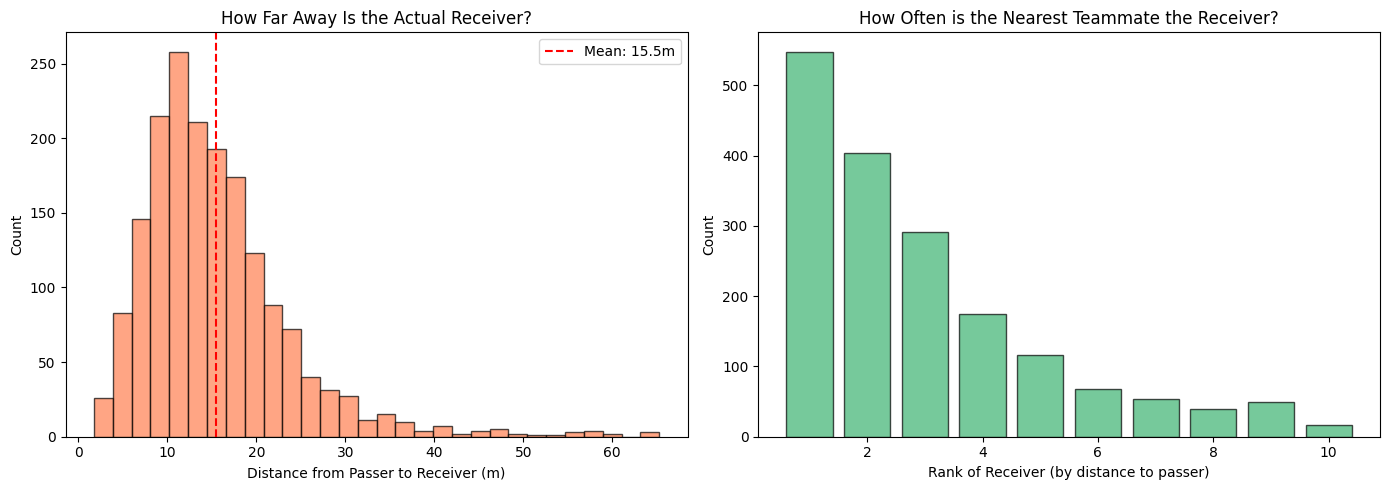

Receiver distance: mean=15.5m, median=13.9m
Nearest teammate is receiver: 548/1761 (31.1%)


In [ ]:
# --- Passer-to-Receiver Distance & Receiver Rank by Distance ---
receiver_dists = []
receiver_ranks = []

for s in all_samples:
    px, py = s['passer_x'], s['passer_y']
    teammates = s['teammates']
    receiver_idx = s['receiver_idx']

    dists = []
    for i, t in enumerate(teammates):
        d = np.sqrt((t['x'] - px)**2 + (t['y'] - py)**2)
        dists.append((i, d))

    receiver_dist = dists[receiver_idx][1]
    receiver_dists.append(receiver_dist)

    dists_sorted = sorted(dists, key=lambda x: x[1])
    for rank, (idx, _) in enumerate(dists_sorted, 1):
        if idx == receiver_idx:
            receiver_ranks.append(rank)
            break

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(receiver_dists, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Distance from Passer to Receiver (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('How Far Away Is the Actual Receiver?')
axes[0].axvline(np.mean(receiver_dists), color='red', linestyle='--',
                label=f'Mean: {np.mean(receiver_dists):.1f}m')
axes[0].legend()

axes[1].bar(range(1, max(receiver_ranks) + 1),
            [receiver_ranks.count(r) for r in range(1, max(receiver_ranks) + 1)],
            edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1].set_xlabel('Rank of Receiver (by distance to passer)')
axes[1].set_ylabel('Count')
axes[1].set_title('How Often is the Nearest Teammate the Receiver?')

plt.tight_layout()
plt.show()

print(f"Receiver distance: mean={np.mean(receiver_dists):.1f}m, median={np.median(receiver_dists):.1f}m")
print(f"Nearest teammate is receiver: {receiver_ranks.count(1)}/{len(receiver_ranks)} "
      f"({receiver_ranks.count(1)/len(receiver_ranks)*100:.1f}%)")

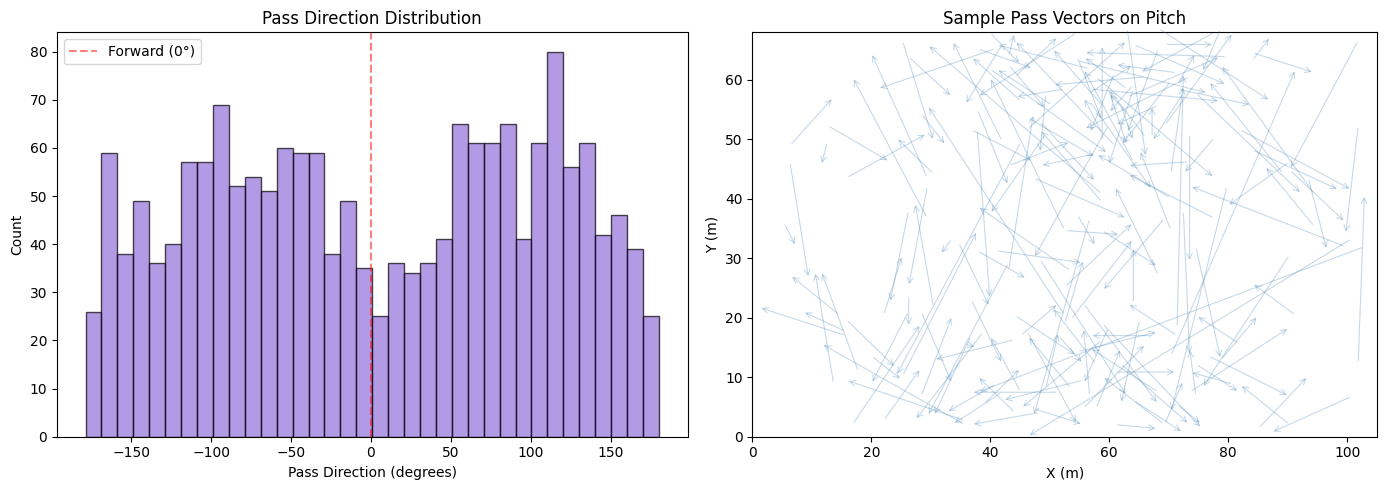

In [ ]:
# --- Pass Direction (Angle) Distribution ---
dx = pass_events['End X'].values - pass_events['Start X'].values
dy = pass_events['End Y'].values - pass_events['Start Y'].values
angles = np.arctan2(dy, dx)  # radians

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of angles
axes[0].hist(np.degrees(angles), bins=36, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[0].set_xlabel('Pass Direction (degrees)')
axes[0].set_ylabel('Count')
axes[0].set_title('Pass Direction Distribution')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5, label='Forward (0°)')
axes[0].legend()

# Scatter plot: pass vectors (arrows from origin to destination for a sample)
sample_idx = np.random.choice(len(pass_events), size=min(200, len(pass_events)), replace=False)
sampled = pass_events.iloc[sample_idx]
for _, row in sampled.iterrows():
    axes[1].annotate('', xy=(row['End X'], row['End Y']),
                     xytext=(row['Start X'], row['Start Y']),
                     arrowprops=dict(arrowstyle='->', color='steelblue', alpha=0.3, lw=0.8))

axes[1].set_xlim(0, PITCH_LENGTH)
axes[1].set_ylim(0, PITCH_WIDTH)
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].set_title('Sample Pass Vectors on Pitch')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

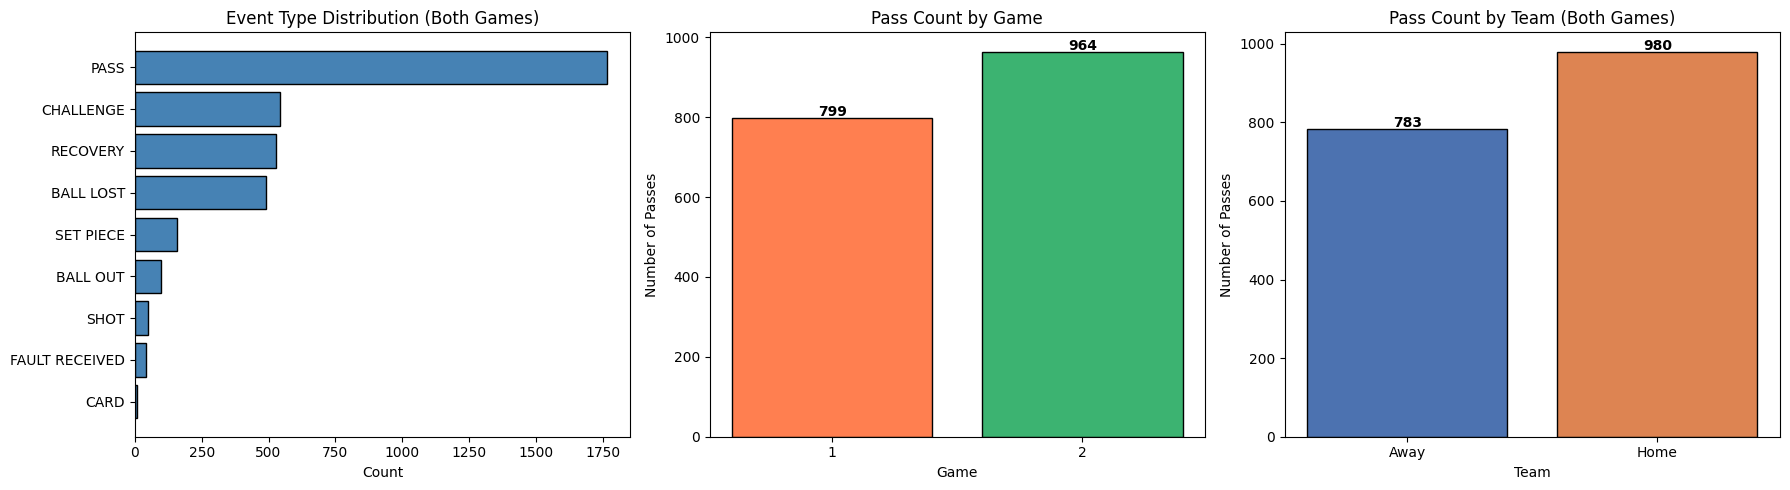

In [ ]:
# --- Event Type Breakdown & Pass Counts by Game/Team ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Event type counts
event_counts = all_events['Type'].value_counts()
axes[0].barh(event_counts.index, event_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Count')
axes[0].set_title('Event Type Distribution (Both Games)')
axes[0].invert_yaxis()

# Passes by game
game_pass_counts = pass_events.groupby('game_id').size()
axes[1].bar(game_pass_counts.index.astype(str), game_pass_counts.values,
            color=['coral', 'mediumseagreen'], edgecolor='black')
axes[1].set_xlabel('Game')
axes[1].set_ylabel('Number of Passes')
axes[1].set_title('Pass Count by Game')
for i, (g, c) in enumerate(zip(game_pass_counts.index, game_pass_counts.values)):
    axes[1].text(i, c + 5, str(c), ha='center', fontweight='bold')

# Passes by team across both games
team_pass_counts = pass_events.groupby('Team').size()
axes[2].bar(team_pass_counts.index, team_pass_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[2].set_xlabel('Team')
axes[2].set_ylabel('Number of Passes')
axes[2].set_title('Pass Count by Team (Both Games)')
for i, (t, c) in enumerate(zip(team_pass_counts.index, team_pass_counts.values)):
    axes[2].text(i, c + 5, str(c), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

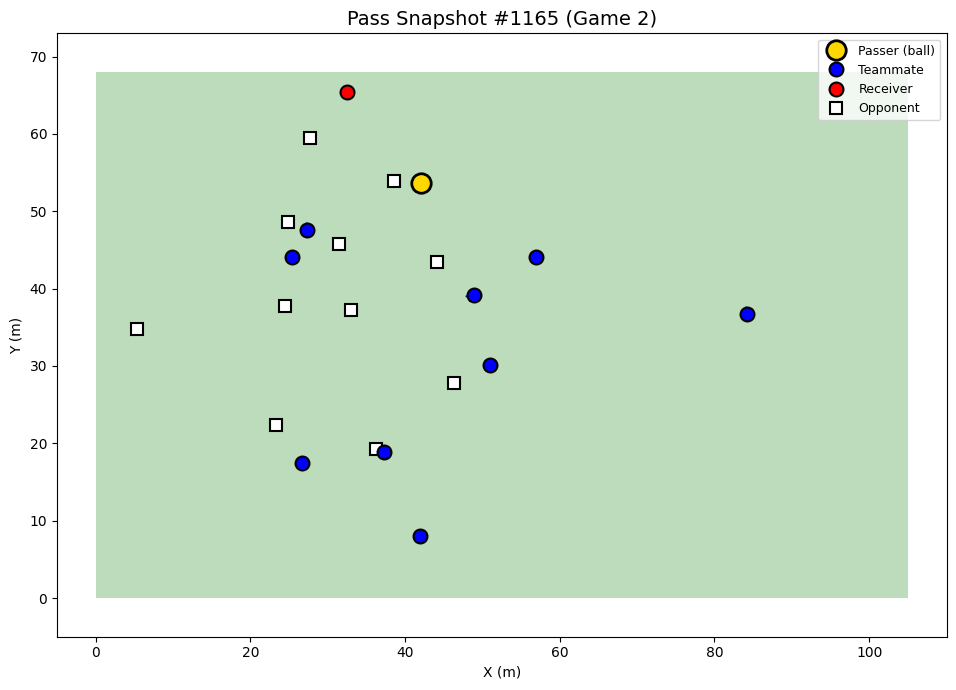

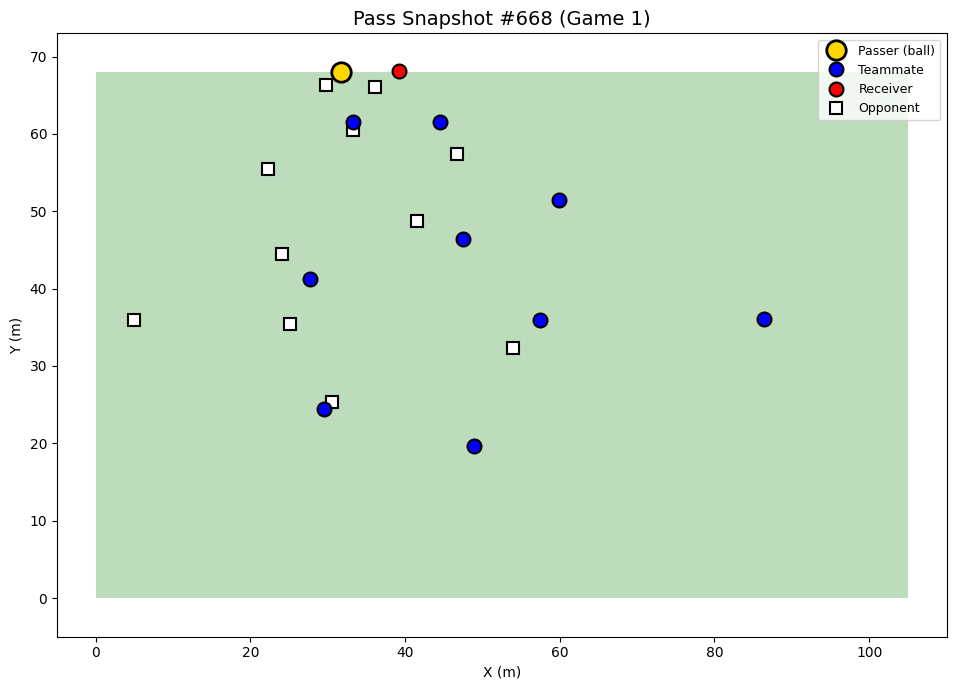

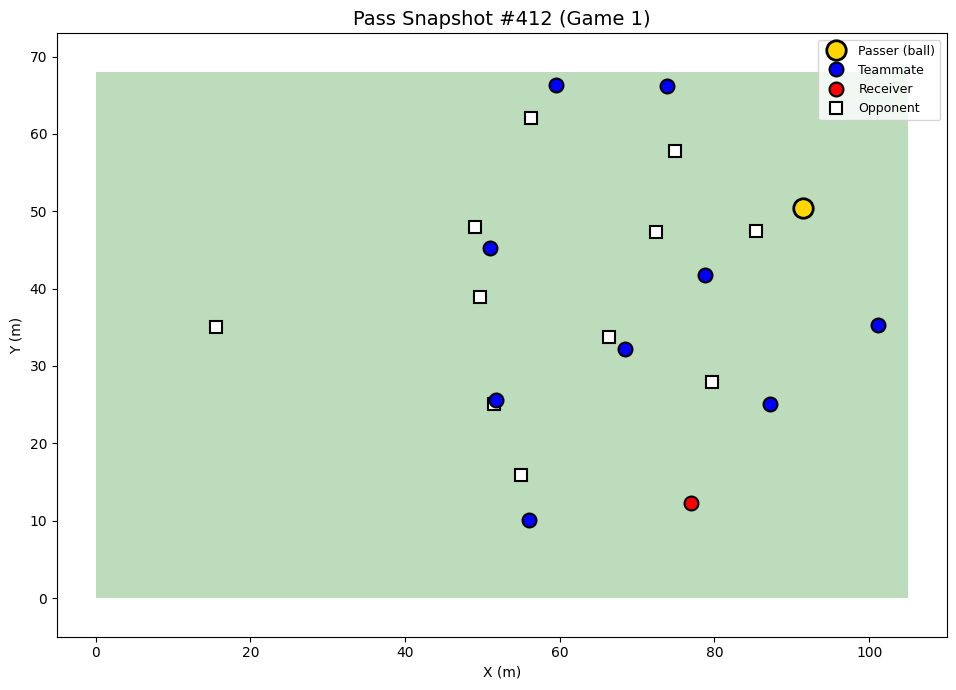

In [ ]:
# --- Visualize a single pass snapshot (player positions at pass moment) ---
def plot_pass_snapshot(sample, idx=0):
    """Visualize a pass: passer, teammates, opponents, and the actual receiver."""
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.set_xlim(-5, PITCH_LENGTH + 5)
    ax.set_ylim(-5, PITCH_WIDTH + 5)
    ax.set_aspect('equal')
    ax.add_patch(plt.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH,
                                fill=True, facecolor='#228B22', alpha=0.3))

    px, py = sample['passer_x'], sample['passer_y']
    ax.plot(px, py, 'o', color='gold', markersize=14, markeredgecolor='black',
            markeredgewidth=2, label='Passer (ball)', zorder=5)

    receiver_idx = sample['receiver_idx']
    for i, t in enumerate(sample['teammates']):
        color = 'red' if i == receiver_idx else 'blue'
        label = 'Receiver' if i == receiver_idx else ('Teammate' if i == 0 else None)
        ax.plot(t['x'], t['y'], 'o', color=color, markersize=10,
                markeredgecolor='black', markeredgewidth=1.5, label=label, zorder=4)

        if t['vx'] != 0 or t['vy'] != 0:
            ax.annotate('', xy=(t['x'] + t['vx'] * 0.3, t['y'] + t['vy'] * 0.3),
                        xytext=(t['x'], t['y']),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    for j, o in enumerate(sample['opponents']):
        ax.plot(o['x'], o['y'], 's', color='white', markersize=8,
                markeredgecolor='black', markeredgewidth=1.5,
                label='Opponent' if j == 0 else None, zorder=3)

    ax.set_title(f'Pass Snapshot #{idx} (Game {sample["game_id"]})', fontsize=14)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()


np.random.seed(0)
for i in np.random.choice(len(all_samples), size=3, replace=False):
    plot_pass_snapshot(all_samples[i], idx=i)

## 3. Baselines

**Nearest Teammate:** For each pass, predict the receiver as the teammate closest to the ball carrier.

**Random:** A trivial lower-bound baseline — pick a random teammate as the receiver. This represents the expected performance when the model has no useful information about pass intent.

In [ ]:
def evaluate_predictions(samples, get_ranking_fn):
    """
    Evaluate predictions using top-1 accuracy, top-3 accuracy, and average rank.

    Args:
        samples: list of pass sample dicts
        get_ranking_fn: function(sample) -> list of teammate indices sorted by
                        predicted probability (most likely first)
    Returns:
        dict with top1_acc, top3_acc, avg_rank
    """
    top1_correct = 0
    top3_correct = 0
    total_rank = 0
    n = len(samples)

    for sample in samples:
        ranking = get_ranking_fn(sample)
        true_idx = sample['receiver_idx']

        if ranking[0] == true_idx:
            top1_correct += 1

        if true_idx in ranking[:3]:
            top3_correct += 1

        rank = ranking.index(true_idx) + 1  # 1-indexed
        total_rank += rank

    return {
        'top1_acc': top1_correct / n * 100,
        'top3_acc': top3_correct / n * 100,
        'avg_rank': total_rank / n,
    }


def nearest_teammate_ranking(sample):
    """
    Rank teammates by distance to the passer (nearest first).
    """
    passer_x, passer_y = sample['passer_x'], sample['passer_y']
    distances = []
    for i, t in enumerate(sample['teammates']):
        dist = np.sqrt((t['x'] - passer_x)**2 + (t['y'] - passer_y)**2)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return [idx for idx, _ in distances]


# Split by game for leave-one-game-out evaluation
game1_samples = [s for s in all_samples if s['game_id'] == 1]
game2_samples = [s for s in all_samples if s['game_id'] == 2]

print("=== Nearest Teammate Baseline ===")
print(f"\nGame 1 samples: {len(game1_samples)}")
print(f"Game 2 samples: {len(game2_samples)}")

# Evaluate on each game
for name, samples in [('Game 1', game1_samples), ('Game 2', game2_samples), ('All', all_samples)]:
    results = evaluate_predictions(samples, nearest_teammate_ranking)
    print(f"\n{name}:")
    print(f"  Top-1 Accuracy: {results['top1_acc']:.1f}%")
    print(f"  Top-3 Accuracy: {results['top3_acc']:.1f}%")
    print(f"  Average Rank:   {results['avg_rank']:.2f}")

# Store Game 2 results for later comparison
nearest_results = evaluate_predictions(game2_samples, nearest_teammate_ranking)
t1_nearest = nearest_results['top1_acc'] / 100
t3_nearest = nearest_results['top3_acc'] / 100

=== Nearest Teammate Baseline ===

Game 1 samples: 797
Game 2 samples: 964

Game 1:
  Top-1 Accuracy: 29.0%
  Top-3 Accuracy: 67.9%
  Average Rank:   3.08

Game 2:
  Top-1 Accuracy: 32.9%
  Top-3 Accuracy: 72.7%
  Average Rank:   2.87

All:
  Top-1 Accuracy: 31.1%
  Top-3 Accuracy: 70.5%
  Average Rank:   2.97


Random Baseline

In [ ]:
def random_ranking(sample):
    """
    Random baseline: shuffle teammate indices uniformly at random.
    Represents the 'ball doesn't move' / no-information scenario.
    """
    n = sample['num_teammates']
    order = list(range(n))
    np.random.shuffle(order)
    return order


np.random.seed(42)

print("=== Random Baseline ===")

# Run multiple trials to get stable expected values
n_trials = 1000
all_results = {name: {'top1': [], 'top3': [], 'rank': []} for name in ['Game 1', 'Game 2', 'All']}

for trial in range(n_trials):
    for name, samps in [('Game 1', game1_samples), ('Game 2', game2_samples), ('All', all_samples)]:
        results = evaluate_predictions(samps, random_ranking)
        all_results[name]['top1'].append(results['top1_acc'])
        all_results[name]['top3'].append(results['top3_acc'])
        all_results[name]['rank'].append(results['avg_rank'])

for name in ['Game 1', 'Game 2', 'All']:
    t1 = np.mean(all_results[name]['top1'])
    t3 = np.mean(all_results[name]['top3'])
    ar = np.mean(all_results[name]['rank'])
    print(f"\n{name}:")
    print(f"  Top-1 Accuracy: {t1:.1f}%")
    print(f"  Top-3 Accuracy: {t3:.1f}%")
    print(f"  Average Rank:   {ar:.2f}")

print("\n(Averaged over 1000 random trials for stability)")

# Store Game 2 results for later comparison
t1_random = np.mean(all_results['Game 2']['top1']) / 100
t3_random = np.mean(all_results['Game 2']['top3']) / 100

=== Random Baseline ===

Game 1:
  Top-1 Accuracy: 10.0%
  Top-3 Accuracy: 30.0%
  Average Rank:   5.50

Game 2:
  Top-1 Accuracy: 10.0%
  Top-3 Accuracy: 30.0%
  Average Rank:   5.50

All:
  Top-1 Accuracy: 10.0%
  Top-3 Accuracy: 30.0%
  Average Rank:   5.50

(Averaged over 1000 random trials for stability)


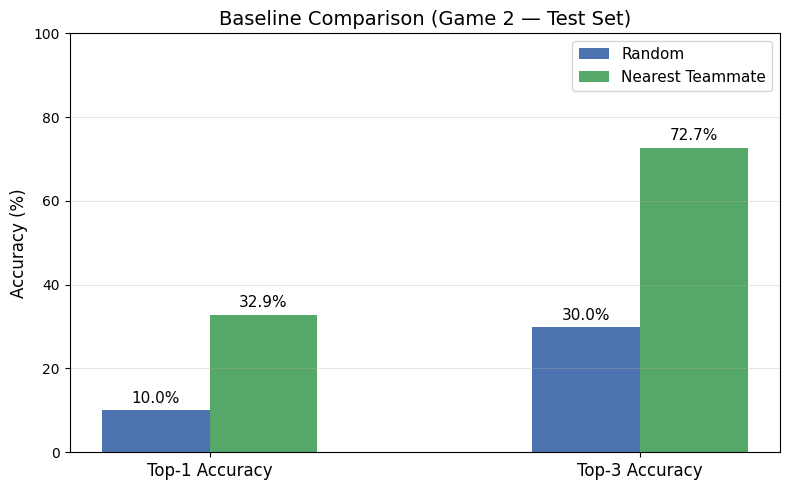

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

metrics = ['Top-1 Accuracy', 'Top-3 Accuracy']
random_vals  = [t1_random * 100,  t3_random * 100]
nearest_vals = [t1_nearest * 100, t3_nearest * 100]

x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width/2, random_vals,  width, label='Random',            color='#4C72B0')
bars2 = ax.bar(x + width/2, nearest_vals, width, label='Nearest Teammate',  color='#55A868')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Baseline Comparison (Game 2 — Test Set)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Logistic Regression

Here, we will implement logistic regression using scikit learn

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
def opp_in_lane(passer, receiver, opponents, lane_width=1.0):
  """
  Check how many opponents are in the same lane as the receiver.
  """
  pr = receiver - passer
  pr_len = np.linalg.norm(pr)
  if pr_len == 0:
    return 0

  pr_unit = pr / pr_len
  count = 0
  for opp in opponents:
    po = np.array([opp['x'], opp['y']]) - passer
    proj_len = np.dot(po, pr_unit)
    if proj_len < 0 or proj_len > pr_len:
      continue

    perp_dist = np.linalg.norm(po - proj_len * pr_unit)
    if perp_dist < lane_width:
      count += 1

  return count

In [ ]:
def build_candidate_features(samples):
  """
  function to build candidate features for logistic regression

  Parameters:
    - samples: list of pass sample dicts

  Returns:
    - X: numpy array of shape (n_samples, n_features) with candidate features
    - y: numpy array of shape (n_samples,) with labels (0 or 1)

  Features are created as:
    - dist_passer_to_receiver       (how far is the pass)
    - angle_to_receiver             (direction of the pass)
    - dist_receiver_to_nearest_opp  (how open is the receiver)
    - receiver_vx, receiver_vy      (where are they moving)
    ## NEW FEATURES POST MILESTONE ##
    - receiver_x, receiver_y        (where is the receiver)
    - n_opps_in_lane                (how many opponents are in the same lane as the receiver)
    - nearest_opp_to_passer         (how far is the nearest opponent to the passer - how much pressure)
  """
  X = []
  y = []

  for sample in samples:
    passer = np.array([sample['passer_x'], sample['passer_y']])

    # nearest opp to passer
    nearest_opp_dist_to_passer = np.inf
    for opp in sample['opponents']:
      opp_dist = np.linalg.norm(np.array([opp['x'], opp['y']]) - passer)
      if opp_dist < nearest_opp_dist_to_passer:
        nearest_opp_dist_to_passer = opp_dist

    for i, teammate in enumerate(sample['teammates']):
      receiver = np.array([teammate['x'], teammate['y']])

      dist = np.linalg.norm(receiver - passer)
      angle = np.arctan2(teammate['y'] - sample['passer_y'],
                               teammate['x'] - sample['passer_x'])

      nearest_opp_dist_to_rec = np.inf
      for opp in sample['opponents']:
        opp_dist = np.linalg.norm(np.array([opp['x'], opp['y']]) - receiver)
        if opp_dist < nearest_opp_dist_to_rec:
          nearest_opp_dist_to_rec = opp_dist

      n_opps_in_lane = opp_in_lane(passer, receiver, sample['opponents'])


      X.append([dist, angle, nearest_opp_dist_to_rec, teammate['vx'], teammate['vy'],
                teammate['x'], teammate['y'], n_opps_in_lane, nearest_opp_dist_to_passer])
      y.append(1 if i == sample['receiver_idx'] else 0)

  return np.array(X), np.array(y)

### Choosing Splits for Train and Test -- Same as above baselines

These will be used for all ML models to follow

In [ ]:
# Train split using game 1
X_train, y_train = build_candidate_features(game1_samples)

# Test split using game 2
X_test, y_test = build_candidate_features(game2_samples)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Shape checking of examples / features

print(X_train.shape)
print(y_train.shape)
print(f"Number of pass events: {len(game1_samples)}")
print(f"Positive labels (actual passes): {y_train.sum()}")

(7970, 9)
(7970,)
Number of pass events: 797
Positive labels (actual passes): 797


In [ ]:
# Helper functions for Logistic Regression

# Sigmoid activation
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# Training loop for Logistic Regression
def train_logistic(X, y, learning_rate=0.01, num_iterations=2000):
  w = np.zeros(X.shape[1])
  b = 0

  m = X.shape[0]

  for epoch in range(num_iterations):
    fwb = np.dot(X, w) + b
    g = sigmoid(fwb)
    cost = - (1 / m) * np.sum(y * np.log(g) + (1 - y) * np.log(1 - g))

    error = g - y

    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 100 == 0:
      print("="*100)
      print(f"Epoch {epoch}: Cost = {cost}")

  return w, b

# Testing implementation for Logistic Regression (using argmax)
def test_logistic(X, y, w, b, num_teammates=10):
  """
  Implement evaluation logic = Argmax because we take the highest
  probability as the predicted class.
  """
  probs = sigmoid(np.dot(X, w) + b)

  n_events = len(y) // num_teammates

  probs_grouped = probs.reshape(n_events, num_teammates)
  labels_grouped = y.reshape(n_events, num_teammates)

  actual = np.argmax(labels_grouped, axis=1)

  # top-1
  predicted = np.argmax(probs_grouped, axis=1)
  t1 = np.mean(predicted == actual)

  # top-3
  t3_preds = np.argsort(-probs_grouped, axis=1)[:, :3]  # top 3 indices per event
  t3 = np.mean([actual[i] in t3_preds[i] for i in range(n_events)])

  print(f"\nGame 2 Logistic Regression:")
  print(f"  Top-1 Accuracy: {t1:.1%}")
  print(f"  Top-3 Accuracy: {t3:.1%}")

  return t1, t3

In [ ]:
# Training Logistic Regression on game 1

w, b = train_logistic(X_train, y_train, learning_rate=0.1)

Epoch 0: Cost = 0.6931471805599453
Epoch 100: Cost = 0.3154042241383413
Epoch 200: Cost = 0.289687810939439
Epoch 300: Cost = 0.2815367971971149
Epoch 400: Cost = 0.2775091358278702
Epoch 500: Cost = 0.27516412934134143
Epoch 600: Cost = 0.2736823904354202
Epoch 700: Cost = 0.2726985060268848
Epoch 800: Cost = 0.2720229359236162
Epoch 900: Cost = 0.27154771935863503
Epoch 1000: Cost = 0.27120730003444976
Epoch 1100: Cost = 0.27095997336888744
Epoch 1200: Cost = 0.2707782541524248
Epoch 1300: Cost = 0.27064352146077736
Epoch 1400: Cost = 0.27054287902559243
Epoch 1500: Cost = 0.2704672344945389
Epoch 1600: Cost = 0.27041008278517953
Epoch 1700: Cost = 0.2703667128819783
Epoch 1800: Cost = 0.2703336780556746
Epoch 1900: Cost = 0.27030843472895216


### Logistic Regression Testing

In [ ]:
# testing logistic regression on game 2

print("=== Logistic Regression Testing ===")
t1LR, t3LR = test_logistic(X_test, y_test, w, b)

=== Logistic Regression Testing ===

Game 2 Logistic Regression:
  Top-1 Accuracy: 39.1%
  Top-3 Accuracy: 77.7%


## 5. Neural Network (Sigmoid)

Here, we will implement a neural network using sigmoid activation

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers

In [ ]:
# Setting up model using sequential, dense, and then Adam optimizer as used in Coursera,
# as well as BCE loss and L2 regularization
sig_model = Sequential([
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# BCE loss
loss_fn = tf.keras.losses.BinaryCrossentropy()

In [ ]:
# Training loop

def train_neural(X, y, model, optimizer, loss_fn, num_iterations=300):
  for epoch in range(num_iterations):
    with tf.GradientTape() as tape:
      y_pred = model(X, training=True)
      loss = loss_fn(y, y_pred)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if epoch % 10 == 0:
      print(f"Epoch {epoch}: Loss = {loss.numpy()}")


def test_neural(X, y, model, num_teammates=10):
  y_pred = model(X, training=False)
  n_events = len(y) // num_teammates

  y_pred = tf.reshape(y_pred, (n_events, num_teammates))
  y = tf.reshape(y, (n_events, num_teammates))

  actual = np.argmax(y, axis=1)

  # Top-1
  predicted = np.argmax(y_pred, axis=1)
  t1 = np.mean(predicted == actual)

  # Top-3
  t3_preds = np.argsort(-y_pred, axis=1)[:, :3]  # top 3 indices per event
  t3 = np.mean([actual[i] in t3_preds[i] for i in range(n_events)])

  print(f"\nGame 2 Neural Network (Sigmoid):")
  print(f"  Top-1 Accuracy: {t1:.1%}")
  print(f"  Top-3 Accuracy: {t3:.1%}")

  return t1, t3


In [ ]:
# Implementation

train_neural(X_train, y_train, sig_model, optimizer, loss_fn, num_iterations=500)

Epoch 0: Loss = 0.695094108581543
Epoch 10: Loss = 0.36000856757164
Epoch 20: Loss = 0.32512539625167847
Epoch 30: Loss = 0.29986000061035156
Epoch 40: Loss = 0.28265857696533203
Epoch 50: Loss = 0.2703668177127838
Epoch 60: Loss = 0.26136404275894165
Epoch 70: Loss = 0.2551729679107666
Epoch 80: Loss = 0.2508009076118469
Epoch 90: Loss = 0.24727731943130493
Epoch 100: Loss = 0.2442733198404312
Epoch 110: Loss = 0.24187582731246948
Epoch 120: Loss = 0.2402278482913971
Epoch 130: Loss = 0.23883819580078125
Epoch 140: Loss = 0.23751838505268097
Epoch 150: Loss = 0.2364266961812973
Epoch 160: Loss = 0.23544763028621674
Epoch 170: Loss = 0.23452048003673553
Epoch 180: Loss = 0.2336241900920868
Epoch 190: Loss = 0.2327774167060852
Epoch 200: Loss = 0.23199708759784698
Epoch 210: Loss = 0.23125305771827698
Epoch 220: Loss = 0.23057006299495697
Epoch 230: Loss = 0.22987698018550873
Epoch 240: Loss = 0.22924135625362396
Epoch 250: Loss = 0.2285662442445755
Epoch 260: Loss = 0.22788548469543457

### Sigmoid Neural Network Testing

In [ ]:
# Testing Sigmoid Neural Network

print("=== Sigmoid Neural Network Testing ===")
t1NN_sig, t3NN_sig = test_neural(X_test, y_test, sig_model)

=== Sigmoid Neural Network Testing ===

Game 2 Neural Network (Sigmoid):
  Top-1 Accuracy: 44.6%
  Top-3 Accuracy: 80.5%


## 6. Neural Network (Softmax)

Here, we will further improve our neural network's accuracy by using softmax


In [ ]:
# First, we need to restructure the data to be readable for softmax
# right now, its (n_samples, n_features) --> needs to be (n_events, 90)
# 90 is the 9 features of the 10 teammates concatenated together and the
# label is which teammate actually recieved the pass

def restructure_data(samples):
  """
  Reusing build_candidate_features but returning different output

  Features are created as:
    - dist_passer_to_receiver       (how far is the pass)
    - angle_to_receiver             (direction of the pass)
    - dist_receiver_to_nearest_opp  (how open is the receiver)
    - receiver_vx, receiver_vy      (where are they moving)
    ## NEW FEATURES POST MILESTONE ##
    - receiver_x, receiver_y        (where is the receiver)
    - n_opps_in_lane                (how many opponents are in the same lane as the receiver)
    - nearest_opp_to_passer         (how far is the nearest opponent to the passer - how much pressure)w
  """

  X = []
  y = []

  for sample in samples:
    passer = np.array([sample['passer_x'], sample['passer_y']])
    sample_feats = []

    # nearest opp to passer
    nearest_opp_dist_to_passer = np.inf
    for opp in sample['opponents']:
      opp_dist = np.linalg.norm(np.array([opp['x'], opp['y']]) - passer)
      if opp_dist < nearest_opp_dist_to_passer:
        nearest_opp_dist_to_passer = opp_dist

    for teammate in sample['teammates']:
      receiver = np.array([teammate['x'], teammate['y']])

      dist = np.linalg.norm(receiver - passer)
      angle = np.arctan2(teammate['y'] - sample['passer_y'],
                               teammate['x'] - sample['passer_x'])

      nearest_opp_dist_to_rec = np.inf
      for opp in sample['opponents']:
        opp_dist = np.linalg.norm(np.array([opp['x'], opp['y']]) - receiver)
        if opp_dist < nearest_opp_dist_to_rec:
          nearest_opp_dist_to_rec = opp_dist

      n_opps_in_lane = opp_in_lane(passer, receiver, sample['opponents'])


      # instead, create sample feature and concat all candidates
      sample_feats.extend([dist, angle, nearest_opp_dist_to_rec, teammate['vx'], teammate['vy'],
                           teammate['x'], teammate['y'], n_opps_in_lane, nearest_opp_dist_to_passer])

    X.append(sample_feats)
    y.append(sample['receiver_idx'])

  return np.array(X), np.array(y)

In [ ]:
# Train split using game 1
X_train_soft, y_train_soft = restructure_data(game1_samples)

# Test split using game 2
X_test_soft, y_test_soft = restructure_data(game2_samples)

scaler = StandardScaler()
X_train_soft = scaler.fit_transform(X_train_soft)
X_test_soft = scaler.transform(X_test_soft)

In [ ]:
# Shape checking of examples / features

print(X_train_soft.shape)
print(y_train_soft.shape)
print(f"Number of pass events: {len(game1_samples)}")
print(f"Positive labels (actual passes): {y_train.sum()}")

(797, 90)
(797,)
Number of pass events: 797
Positive labels (actual passes): 797


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
smax_model = Sequential([
    Dense(50, activation='relu', kernel_regularizer=regularizers.l2(0.1)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.1)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Sparse categorical cross entropy because many output classes
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

In [ ]:
# Helpers for Softmax Neural Network

# Can reuse train_neural

# Test Softmax Neural Network
def test_softmax_neural(X, y, smax_model):
    y_pred = smax_model(X, training=False).numpy()


    # Top-1
    predicted = np.argmax(y_pred, axis=1)
    t1 = np.mean(predicted == y)

    # Top-3
    top3_preds = np.argsort(-y_pred, axis=1)[:, :3]
    t3 = np.mean([y[i] in top3_preds[i] for i in range(len(y))])

    print("\nGame 2 Neural Network (Softmax):")
    print(f"  Top-1 Accuracy: {t1:.1%}")
    print(f"  Top-3 Accuracy: {t3:.1%}")

    return t1, t3

In [ ]:
# Training Softmax Neural Network

train_neural(X_train_soft, y_train_soft, smax_model, optimizer, loss_fn, num_iterations=500)

Epoch 0: Loss = 3.2456626892089844
Epoch 10: Loss = 2.6648898124694824
Epoch 20: Loss = 2.4478213787078857
Epoch 30: Loss = 2.307440996170044
Epoch 40: Loss = 2.251337766647339
Epoch 50: Loss = 2.1980254650115967
Epoch 60: Loss = 2.154991626739502
Epoch 70: Loss = 2.104222536087036
Epoch 80: Loss = 2.1020243167877197
Epoch 90: Loss = 2.029261589050293
Epoch 100: Loss = 2.0182909965515137
Epoch 110: Loss = 1.9612380266189575
Epoch 120: Loss = 1.9557777643203735
Epoch 130: Loss = 1.9140820503234863
Epoch 140: Loss = 1.879758596420288
Epoch 150: Loss = 1.830357551574707
Epoch 160: Loss = 1.8103572130203247
Epoch 170: Loss = 1.756749153137207
Epoch 180: Loss = 1.7396819591522217
Epoch 190: Loss = 1.7130376100540161
Epoch 200: Loss = 1.6644325256347656
Epoch 210: Loss = 1.675950527191162
Epoch 220: Loss = 1.603594183921814
Epoch 230: Loss = 1.5896652936935425
Epoch 240: Loss = 1.5676162242889404
Epoch 250: Loss = 1.5444283485412598
Epoch 260: Loss = 1.5034964084625244
Epoch 270: Loss = 1.51

### Softmax Neural Network Testing

In [ ]:
# Testing Softmax Neural Network

print("=== Softmax Neural Network Testing ===")
t1NN_soft, t3NN_soft = test_softmax_neural(X_test_soft, y_test_soft, smax_model)

=== Softmax Neural Network Testing ===

Game 2 Neural Network (Softmax):
  Top-1 Accuracy: 25.7%
  Top-3 Accuracy: 55.9%


In [ ]:
# Compare accuracy of Logistic Regression vs Sigmoid Neural Network vs Softmax Neural Network

def compare_all_models(t1LR, t3LR, t1NN_sig, t3NN_sig, t1NN_soft, t3NN_soft):

    print("\n| Model Comparison    | Top-1: | Top-3: |")
    print("-"*41)
    print(f"| Logistic Regression | {t1LR:.1%}  | {t3LR:.1%}  |")
    print(f"| Sigmoid NN          | {t1NN_sig:.1%}  | {t3NN_sig:.1%}  |")
    print(f"| Softmax NN          | {t1NN_soft:.1%}  | {t3NN_soft:.1%}  |")



    if t1NN_soft == max(t1NN_soft, t1NN_sig, t1LR):
        print("\nSoftmax neural network performs the best on Top-1 accuracy.")
    elif t1NN_sig == max(t1NN_soft, t1NN_sig, t1LR):
        print("\nSigmoid neural network performs the best on Top-1 accuracy.")
    else:
        print("\nLogistic regression performs the best on Top-1 accuracy.")

In [ ]:
compare_all_models(t1LR, t3LR, t1NN_sig, t3NN_sig, t1NN_soft, t3NN_soft)


| Model Comparison    | Top-1: | Top-3: |
-----------------------------------------
| Logistic Regression | 39.1%  | 77.7%  |
| Sigmoid NN          | 44.6%  | 80.5%  |
| Softmax NN          | 25.7%  | 55.9%  |

Sigmoid neural network performs the best on Top-1 accuracy.


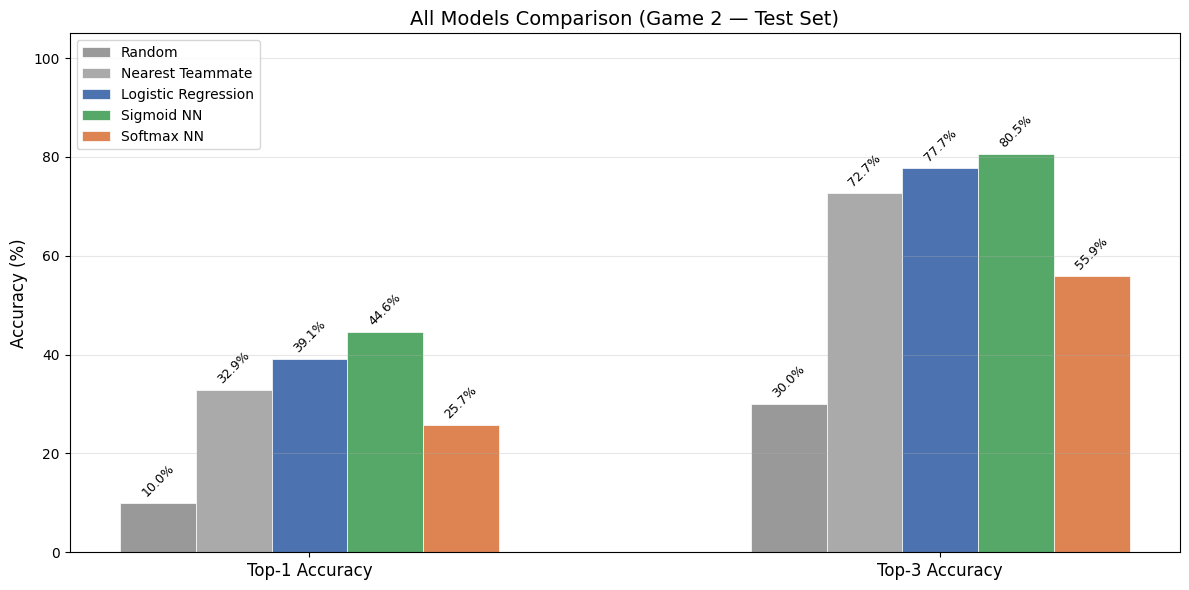

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Top-1 Accuracy', 'Top-3 Accuracy']
model_names  = ['Random', 'Nearest Teammate', 'Logistic Regression', 'Sigmoid NN', 'Softmax NN']
model_colors = ['#999999', '#AAAAAA', '#4C72B0', '#55A868', '#DD8452']

t1_vals = [t1_random * 100, t1_nearest * 100, t1LR * 100, t1NN_sig * 100, t1NN_soft * 100]
t3_vals = [t3_random * 100, t3_nearest * 100, t3LR * 100, t3NN_sig * 100, t3NN_soft * 100]

n_models = len(model_names)
x = np.arange(len(metrics))
width = 0.12
offsets = np.arange(n_models) - (n_models - 1) / 2

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    vals = [t1_vals[i], t3_vals[i]]
    bars = ax.bar(x + offsets[i] * width, vals, width, label=name, color=color,
                  edgecolor='white', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, rotation=45)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('All Models Comparison (Game 2 — Test Set)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Data Augmentation: Y-Axis Reflection

A soccer pitch is symmetric across its long centerline. A pass pattern on the left side of the field is equally valid mirrored to the right side. We exploit this by reflecting all y-coordinates across the pitch midline (`y → PITCH_WIDTH - y`) and negating y-velocities, effectively doubling our training set without introducing any artificial bias.

In [ ]:
import copy

def augment_y_reflection(samples, pitch_width=PITCH_WIDTH):
    """
    Create mirrored copies of pass samples by reflecting across the pitch centerline.
    y -> PITCH_WIDTH - y, vy -> -vy. Labels and teammate ordering stay the same.
    """
    augmented = []
    for sample in samples:
        mirrored = copy.deepcopy(sample)
        mirrored['passer_y'] = pitch_width - sample['passer_y']

        for t in mirrored['teammates']:
            t['y'] = pitch_width - t['y']
            t['vy'] = -t['vy']

        for o in mirrored['opponents']:
            o['y'] = pitch_width - o['y']
            o['vy'] = -o['vy']

        augmented.append(mirrored)
    return augmented

# Augment training set (Game 1) only — test set (Game 2) stays untouched
game1_reflected = augment_y_reflection(game1_samples)
game1_augmented = game1_samples + game1_reflected

print(f"Original training samples (Game 1): {len(game1_samples)}")
print(f"After Y-axis reflection:            {len(game1_augmented)}")
print(f"Test samples (Game 2, unchanged):   {len(game2_samples)}")

Original training samples (Game 1): 797
After Y-axis reflection:            1594
Test samples (Game 2, unchanged):   964


### 7.1 Logistic Regression (Augmented)

In [ ]:
# Build features from augmented training set
X_train_aug, y_train_aug = build_candidate_features(game1_augmented)

scaler_aug = StandardScaler()
X_train_aug = scaler_aug.fit_transform(X_train_aug)
X_test_aug = scaler_aug.transform(build_candidate_features(game2_samples)[0])

print(f"Augmented training shape: {X_train_aug.shape}")
print(f"Test shape (unchanged):   {X_test_aug.shape}")

# Train logistic regression on augmented data
w_aug, b_aug = train_logistic(X_train_aug, y_train_aug, learning_rate=0.1)

# Test on Game 2
print("\n=== Logistic Regression (Augmented) Testing ===")
t1LR_aug, t3LR_aug = test_logistic(X_test_aug, y_test, w_aug, b_aug)

Augmented training shape: (15940, 9)
Test shape (unchanged):   (9640, 9)
Epoch 0: Cost = 0.6931471805599452
Epoch 100: Cost = 0.31552887619397146
Epoch 200: Cost = 0.2898391792149908
Epoch 300: Cost = 0.28169739644768965
Epoch 400: Cost = 0.27767545128090765
Epoch 500: Cost = 0.27533520157606267
Epoch 600: Cost = 0.2738574868936422
Epoch 700: Cost = 0.27287692962104215
Epoch 800: Cost = 0.27220406900970373
Epoch 900: Cost = 0.2717310428367952
Epoch 1000: Cost = 0.27139238883405836
Epoch 1100: Cost = 0.27114648356452736
Epoch 1200: Cost = 0.27096590891844446
Epoch 1300: Cost = 0.27083209839592287
Epoch 1400: Cost = 0.270732199486166
Epoch 1500: Cost = 0.2706571548914961
Epoch 1600: Cost = 0.2706004875865811
Epoch 1700: Cost = 0.2705575090240003
Epoch 1800: Cost = 0.2705247904894677
Epoch 1900: Cost = 0.2704998028727606

=== Logistic Regression (Augmented) Testing ===

Game 2 Logistic Regression:
  Top-1 Accuracy: 39.2%
  Top-3 Accuracy: 77.8%


### 7.2 Sigmoid Neural Network (Augmented)

In [ ]:
# Fresh sigmoid model on augmented data
sig_model_aug = Sequential([
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(1, activation='sigmoid')
])

optimizer_sig_aug = tf.keras.optimizers.Adam(learning_rate=0.01)
loss_fn_sig_aug = tf.keras.losses.BinaryCrossentropy()

# Train on augmented data
train_neural(X_train_aug, y_train_aug, sig_model_aug, optimizer_sig_aug, loss_fn_sig_aug)

# Test on Game 2
print("\n=== Sigmoid NN (Augmented) Testing ===")
t1NN_sig_aug, t3NN_sig_aug = test_neural(X_test_aug, y_test, sig_model_aug)

Epoch 0: Loss = 0.8736774325370789
Epoch 10: Loss = 0.3926609456539154
Epoch 20: Loss = 0.3407575786113739
Epoch 30: Loss = 0.3045423626899719
Epoch 40: Loss = 0.2893868088722229
Epoch 50: Loss = 0.27574437856674194
Epoch 60: Loss = 0.2670532166957855
Epoch 70: Loss = 0.2613093852996826
Epoch 80: Loss = 0.2576393187046051
Epoch 90: Loss = 0.2549719214439392
Epoch 100: Loss = 0.2526741921901703
Epoch 110: Loss = 0.25058817863464355
Epoch 120: Loss = 0.24882064759731293
Epoch 130: Loss = 0.24729399383068085
Epoch 140: Loss = 0.24599137902259827
Epoch 150: Loss = 0.24494893848896027
Epoch 160: Loss = 0.24399548768997192
Epoch 170: Loss = 0.24319055676460266
Epoch 180: Loss = 0.2424461841583252
Epoch 190: Loss = 0.24177463352680206
Epoch 200: Loss = 0.24113070964813232
Epoch 210: Loss = 0.24049992859363556
Epoch 220: Loss = 0.23998302221298218
Epoch 230: Loss = 0.23958724737167358
Epoch 240: Loss = 0.23925241827964783
Epoch 250: Loss = 0.23896051943302155
Epoch 260: Loss = 0.23868614435195

### 7.3 Softmax Neural Network (Augmented)

In [ ]:
# Build softmax-style features from augmented training set
X_train_soft_aug, y_train_soft_aug = restructure_data(game1_augmented)

scaler_soft_aug = StandardScaler()
X_train_soft_aug = scaler_soft_aug.fit_transform(X_train_soft_aug)
X_test_soft_aug = scaler_soft_aug.transform(restructure_data(game2_samples)[0])

print(f"Augmented softmax training shape: {X_train_soft_aug.shape}")
print(f"Test shape (unchanged):           {X_test_soft_aug.shape}")

# Fresh softmax model on augmented data
smax_model_aug = Sequential([
    Dense(50, activation='relu', kernel_regularizer=regularizers.l2(0.1)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.1)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

optimizer_soft_aug = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn_soft_aug = tf.keras.losses.SparseCategoricalCrossentropy()

# Train on augmented data
train_neural(X_train_soft_aug, y_train_soft_aug, smax_model_aug, optimizer_soft_aug,
             loss_fn_soft_aug, num_iterations=500)

# Test on Game 2
print("\n=== Softmax NN (Augmented) Testing ===")
t1NN_soft_aug, t3NN_soft_aug = test_softmax_neural(X_test_soft_aug, y_test_soft, smax_model_aug)

Augmented softmax training shape: (1594, 90)
Test shape (unchanged):           (964, 90)
Epoch 0: Loss = 2.8147783279418945
Epoch 10: Loss = 2.5139667987823486
Epoch 20: Loss = 2.3693227767944336
Epoch 30: Loss = 2.289680242538452
Epoch 40: Loss = 2.267021894454956
Epoch 50: Loss = 2.2345666885375977
Epoch 60: Loss = 2.18611216545105
Epoch 70: Loss = 2.1485252380371094
Epoch 80: Loss = 2.130275249481201
Epoch 90: Loss = 2.1112589836120605
Epoch 100: Loss = 2.0836920738220215
Epoch 110: Loss = 2.0267369747161865
Epoch 120: Loss = 1.9992427825927734
Epoch 130: Loss = 1.978438377380371
Epoch 140: Loss = 1.934596300125122
Epoch 150: Loss = 1.9145960807800293
Epoch 160: Loss = 1.8733024597167969
Epoch 170: Loss = 1.8317662477493286
Epoch 180: Loss = 1.7923997640609741
Epoch 190: Loss = 1.8059331178665161
Epoch 200: Loss = 1.7597447633743286
Epoch 210: Loss = 1.7516142129898071
Epoch 220: Loss = 1.7390364408493042
Epoch 230: Loss = 1.6643680334091187
Epoch 240: Loss = 1.6470447778701782
Epoc

### 7.4 Augmentation Impact: Original vs. Augmented

---



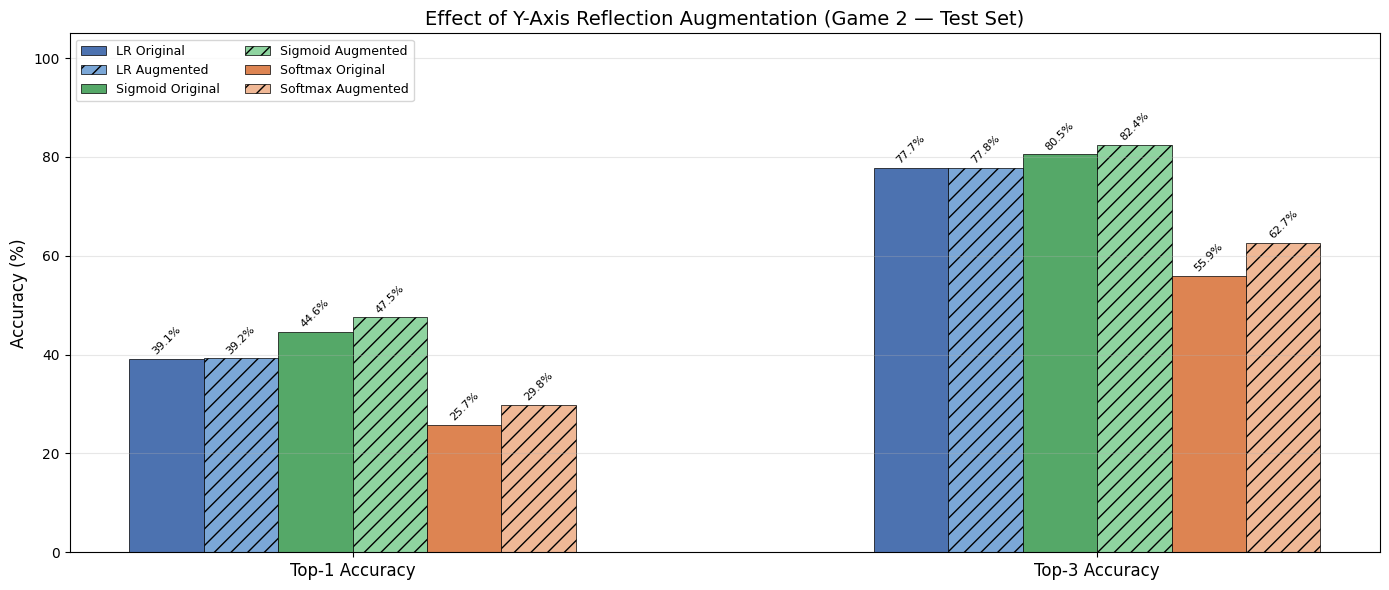

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

metrics = ['Top-1 Accuracy', 'Top-3 Accuracy']
bar_labels = ['LR Original', 'LR Augmented',
              'Sigmoid Original', 'Sigmoid Augmented',
              'Softmax Original', 'Softmax Augmented']
bar_colors = ['#4C72B0', '#7BA7D7',
              '#55A868', '#8FD4A0',
              '#DD8452', '#F0B896']
bar_hatches = ['', '//', '', '//', '', '//']

t1_vals = [t1LR * 100, t1LR_aug * 100,
           t1NN_sig * 100, t1NN_sig_aug * 100,
           t1NN_soft * 100, t1NN_soft_aug * 100]
t3_vals = [t3LR * 100, t3LR_aug * 100,
           t3NN_sig * 100, t3NN_sig_aug * 100,
           t3NN_soft * 100, t3NN_soft_aug * 100]

n_bars = len(bar_labels)
x = np.arange(len(metrics))
width = 0.1
offsets = np.arange(n_bars) - (n_bars - 1) / 2

for i, (name, color, hatch) in enumerate(zip(bar_labels, bar_colors, bar_hatches)):
    vals = [t1_vals[i], t3_vals[i]]
    bars = ax.bar(x + offsets[i] * width, vals, width, label=name, color=color,
                  edgecolor='black', linewidth=0.5, hatch=hatch)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Effect of Y-Axis Reflection Augmentation (Game 2 — Test Set)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Additional Augmentation

We also can reflect the x axis, as well as both the x and y axis together to essentially 4x our original data. The effects of just y axis augmentation are shown above, but the following section will show the effects of original, y axis reflected, x axis reflected, and xy axis reflected data augmentation together.

In [ ]:
import copy

def augment_x_reflection(samples, pitch_length=PITCH_LENGTH):
    """
    Create mirrored copies of pass samples by reflecting across the pitch horizontal centerline.
    x -> PITCH_LENGTH - x, vx -> -vx. Labels and teammate ordering stay the same.
    """
    augmented = []
    for sample in samples:
        mirrored = copy.deepcopy(sample)
        mirrored['passer_x'] = pitch_length - sample['passer_x']

        for t in mirrored['teammates']:
            t['x'] = pitch_length - t['x']
            t['vx'] = -t['vx']

        for o in mirrored['opponents']:
            o['x'] = pitch_length - o['x']
            o['vx'] = -o['vx']

        augmented.append(mirrored)
    return augmented

# Augment training set (Game 1) only — test set (Game 2) stays untouched
game1_y_reflected = augment_y_reflection(game1_samples)
game1_x_reflected = augment_x_reflection(game1_samples)
game1_xy_reflected = augment_x_reflection(game1_y_reflected)
game1_augmented_2 = game1_samples + game1_y_reflected + game1_x_reflected + game1_xy_reflected

print(f"Original training samples (Game 1): {len(game1_samples)}")
print(f"After Y-axis reflection:            {len(game1_augmented_2)}")
print(f"Test samples (Game 2, unchanged):   {len(game2_samples)}")

Original training samples (Game 1): 797
After Y-axis reflection:            3188
Test samples (Game 2, unchanged):   964


### 8.1 Logistic Regression Augmented (x, y, xy)

In [ ]:
# Build features from augmented training set
X_train_aug, y_train_aug = build_candidate_features(game1_augmented_2)

scaler_aug = StandardScaler()
X_train_aug = scaler_aug.fit_transform(X_train_aug)
X_test_aug = scaler_aug.transform(build_candidate_features(game2_samples)[0])

print(f"Augmented training shape: {X_train_aug.shape}")
print(f"Test shape (unchanged):   {X_test_aug.shape}")

# Train logistic regression on augmented data
w_aug, b_aug = train_logistic(X_train_aug, y_train_aug, learning_rate=0.1)

# Test on Game 2
print("\n=== Logistic Regression (Augmented) Testing ===")
t1LR_aug_2, t3LR_aug_2 = test_logistic(X_test_aug, y_test, w_aug, b_aug)

Augmented training shape: (31880, 9)
Test shape (unchanged):   (9640, 9)
Epoch 0: Cost = 0.6931471805599451
Epoch 100: Cost = 0.31559711527488793
Epoch 200: Cost = 0.2899323068379099
Epoch 300: Cost = 0.2818057375164714
Epoch 400: Cost = 0.27779499787135165
Epoch 500: Cost = 0.27546357426978774
Epoch 600: Cost = 0.2739928913668777
Epoch 700: Cost = 0.27301793396978496
Epoch 800: Cost = 0.27234952794465433
Epoch 900: Cost = 0.27188004486797207
Epoch 1000: Cost = 0.2715442110016333
Epoch 1100: Cost = 0.2713005531182653
Epoch 1200: Cost = 0.27112177193804166
Epoch 1300: Cost = 0.27098939467887784
Epoch 1400: Cost = 0.27089064270928637
Epoch 1500: Cost = 0.27081651703471094
Epoch 1600: Cost = 0.27076058672779835
Epoch 1700: Cost = 0.2707181997713234
Epoch 1800: Cost = 0.2706859564673883
Epoch 1900: Cost = 0.27066135080657344

=== Logistic Regression (Augmented) Testing ===

Game 2 Logistic Regression:
  Top-1 Accuracy: 38.9%
  Top-3 Accuracy: 77.9%


### 8.2 Sigmoid Neural Network Augmented (x, y, xy)

In [ ]:
# Fresh sigmoid model on augmented data
sig_model_aug = Sequential([
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(1, activation='sigmoid')
])

optimizer_sig_aug = tf.keras.optimizers.Adam(learning_rate=0.01)
loss_fn_sig_aug = tf.keras.losses.BinaryCrossentropy()

# Train on augmented data
train_neural(X_train_aug, y_train_aug, sig_model_aug, optimizer_sig_aug, loss_fn_sig_aug)

# Test on Game 2
print("\n=== Sigmoid NN (Augmented) Testing ===")
t1NN_sig_aug_2, t3NN_sig_aug_2 = test_neural(X_test_aug, y_test, sig_model_aug)

Epoch 0: Loss = 0.6986880898475647
Epoch 10: Loss = 0.3733930289745331
Epoch 20: Loss = 0.3352370262145996
Epoch 30: Loss = 0.30280911922454834
Epoch 40: Loss = 0.28539761900901794
Epoch 50: Loss = 0.2739059329032898
Epoch 60: Loss = 0.26657673716545105
Epoch 70: Loss = 0.2625437378883362
Epoch 80: Loss = 0.260165810585022
Epoch 90: Loss = 0.25805050134658813
Epoch 100: Loss = 0.25594910979270935
Epoch 110: Loss = 0.25374001264572144
Epoch 120: Loss = 0.25140249729156494
Epoch 130: Loss = 0.24924390017986298
Epoch 140: Loss = 0.24756424129009247
Epoch 150: Loss = 0.2463417798280716
Epoch 160: Loss = 0.24538828432559967
Epoch 170: Loss = 0.24452883005142212
Epoch 180: Loss = 0.24378091096878052
Epoch 190: Loss = 0.24312739074230194
Epoch 200: Loss = 0.2425961047410965
Epoch 210: Loss = 0.24210341274738312
Epoch 220: Loss = 0.2416767030954361
Epoch 230: Loss = 0.24128513038158417
Epoch 240: Loss = 0.2409188598394394
Epoch 250: Loss = 0.24061694741249084
Epoch 260: Loss = 0.24031755328178

### 8.3 Softmax Neural Network Augmented (x, y, xy)

In [ ]:
# Build softmax-style features from augmented training set
X_train_soft_aug, y_train_soft_aug = restructure_data(game1_augmented)

scaler_soft_aug = StandardScaler()
X_train_soft_aug = scaler_soft_aug.fit_transform(X_train_soft_aug)
X_test_soft_aug = scaler_soft_aug.transform(restructure_data(game2_samples)[0])

print(f"Augmented softmax training shape: {X_train_soft_aug.shape}")
print(f"Test shape (unchanged):           {X_test_soft_aug.shape}")

# Fresh softmax model on augmented data
smax_model_aug = Sequential([
    Dense(50, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

optimizer_soft_aug = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn_soft_aug = tf.keras.losses.SparseCategoricalCrossentropy()

# Train on augmented data
train_neural(X_train_soft_aug, y_train_soft_aug, smax_model_aug, optimizer_soft_aug,
             loss_fn_soft_aug, num_iterations=500)

# Test on Game 2
print("\n=== Softmax NN (Augmented) Testing ===")
t1NN_soft_aug_2, t3NN_soft_aug_2 = test_softmax_neural(X_test_soft_aug, y_test_soft, smax_model_aug)

Augmented softmax training shape: (1594, 90)
Test shape (unchanged):           (964, 90)
Epoch 0: Loss = 2.7162246704101562
Epoch 10: Loss = 2.452970266342163
Epoch 20: Loss = 2.343207836151123
Epoch 30: Loss = 2.261732578277588
Epoch 40: Loss = 2.233764171600342
Epoch 50: Loss = 2.192318916320801
Epoch 60: Loss = 2.162559747695923
Epoch 70: Loss = 2.1538357734680176
Epoch 80: Loss = 2.1184918880462646
Epoch 90: Loss = 2.065584897994995
Epoch 100: Loss = 2.0368599891662598
Epoch 110: Loss = 2.028007745742798
Epoch 120: Loss = 1.991140365600586
Epoch 130: Loss = 1.9601250886917114
Epoch 140: Loss = 1.8938853740692139
Epoch 150: Loss = 1.8736485242843628
Epoch 160: Loss = 1.841748833656311
Epoch 170: Loss = 1.797944188117981
Epoch 180: Loss = 1.7999998331069946
Epoch 190: Loss = 1.7488915920257568
Epoch 200: Loss = 1.736272931098938
Epoch 210: Loss = 1.7236700057983398
Epoch 220: Loss = 1.69292151927948
Epoch 230: Loss = 1.6456207036972046
Epoch 240: Loss = 1.6214853525161743
Epoch 250: 

### 8.4 Augmentation Impact: Original vs. Augmented (y) vs. Augmented (x, y, xy)

---


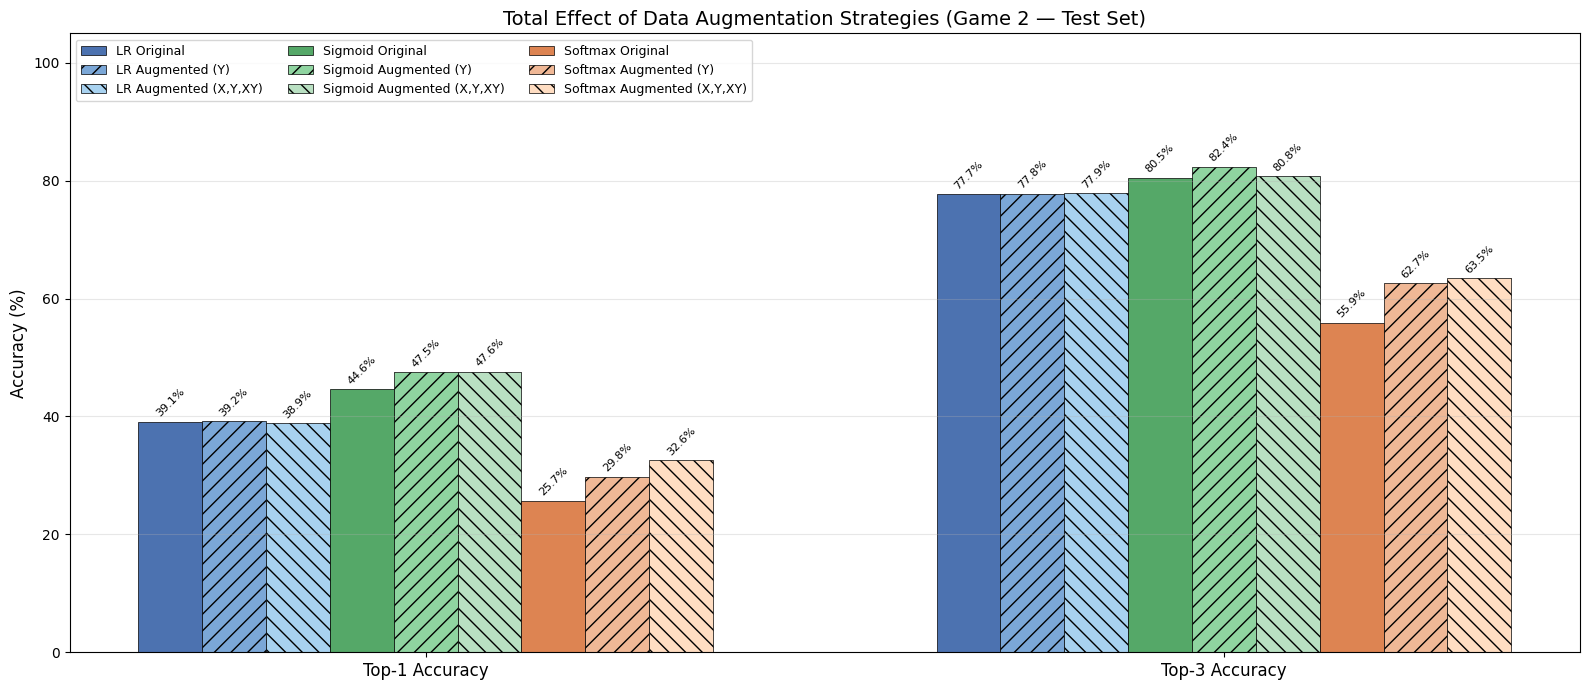

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))

metrics = ['Top-1 Accuracy', 'Top-3 Accuracy']
bar_labels = ['LR Original', 'LR Augmented (Y)', 'LR Augmented (X,Y,XY)',
              'Sigmoid Original', 'Sigmoid Augmented (Y)', 'Sigmoid Augmented (X,Y,XY)',
              'Softmax Original', 'Softmax Augmented (Y)', 'Softmax Augmented (X,Y,XY)']
bar_colors = ['#4C72B0', '#7BA7D7', '#A8D2F0',  # LR colors (Original, Y-aug, XY-aug)
              '#55A868', '#8FD4A0', '#B9E0C2',  # Sigmoid colors
              '#DD8452', '#F0B896', '#FFDDC2']  # Softmax colors
bar_hatches = ['', '//', '\\\\',
               '', '//', '\\\\',
               '', '//', '\\\\'] # Different hatches for visual distinction

t1_vals = [t1LR * 100, t1LR_aug * 100, t1LR_aug_2 * 100,
           t1NN_sig * 100, t1NN_sig_aug * 100, t1NN_sig_aug_2 * 100,
           t1NN_soft * 100, t1NN_soft_aug * 100, t1NN_soft_aug_2 * 100]
t3_vals = [t3LR * 100, t3LR_aug * 100, t3LR_aug_2 * 100,
           t3NN_sig * 100, t3NN_sig_aug * 100, t3NN_sig_aug_2 * 100,
           t3NN_soft * 100, t3NN_soft_aug * 100, t3NN_soft_aug_2 * 100]

n_bars = len(bar_labels)
x = np.arange(len(metrics))
width = 0.08  # Adjusted width for more bars
offsets = np.arange(n_bars) - (n_bars - 1) / 2

for i, (name, color, hatch) in enumerate(zip(bar_labels, bar_colors, bar_hatches)):
    vals = [t1_vals[i], t3_vals[i]]
    bars = ax.bar(x + offsets[i] * width, vals, width, label=name, color=color,
                  edgecolor='black', linewidth=0.5, hatch=hatch)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Total Effect of Data Augmentation Strategies (Game 2 — Test Set)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=9, loc='upper left', ncol=3) # Adjusted ncol for better legend display
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Prediction Heatmap Visualization

For a given pass, we run both the Sigmoid NN and the Softmax NN to get a probability for each candidate teammate. We place a Gaussian blob at each teammate's location, weighted by predicted probability, producing a spatial heatmap of where the model thinks the pass will go.

**Legend:** The **passer** (yellow star) is the player with the ball. **Teammates** (blue circles) are the pass candidates. The **actual receiver** is highlighted green, and the **model's top prediction** is highlighted with a gold edge. **Opponents** are shown as red squares.

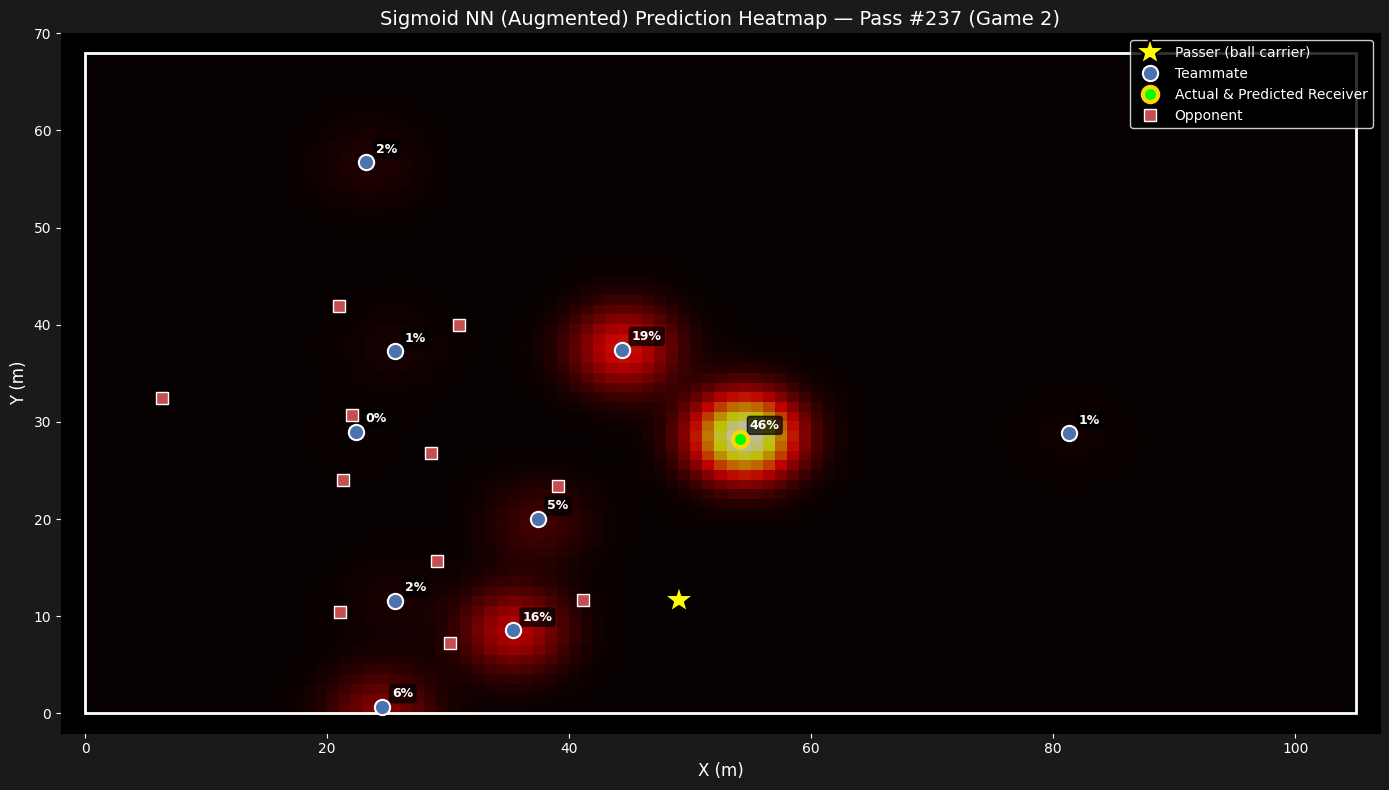

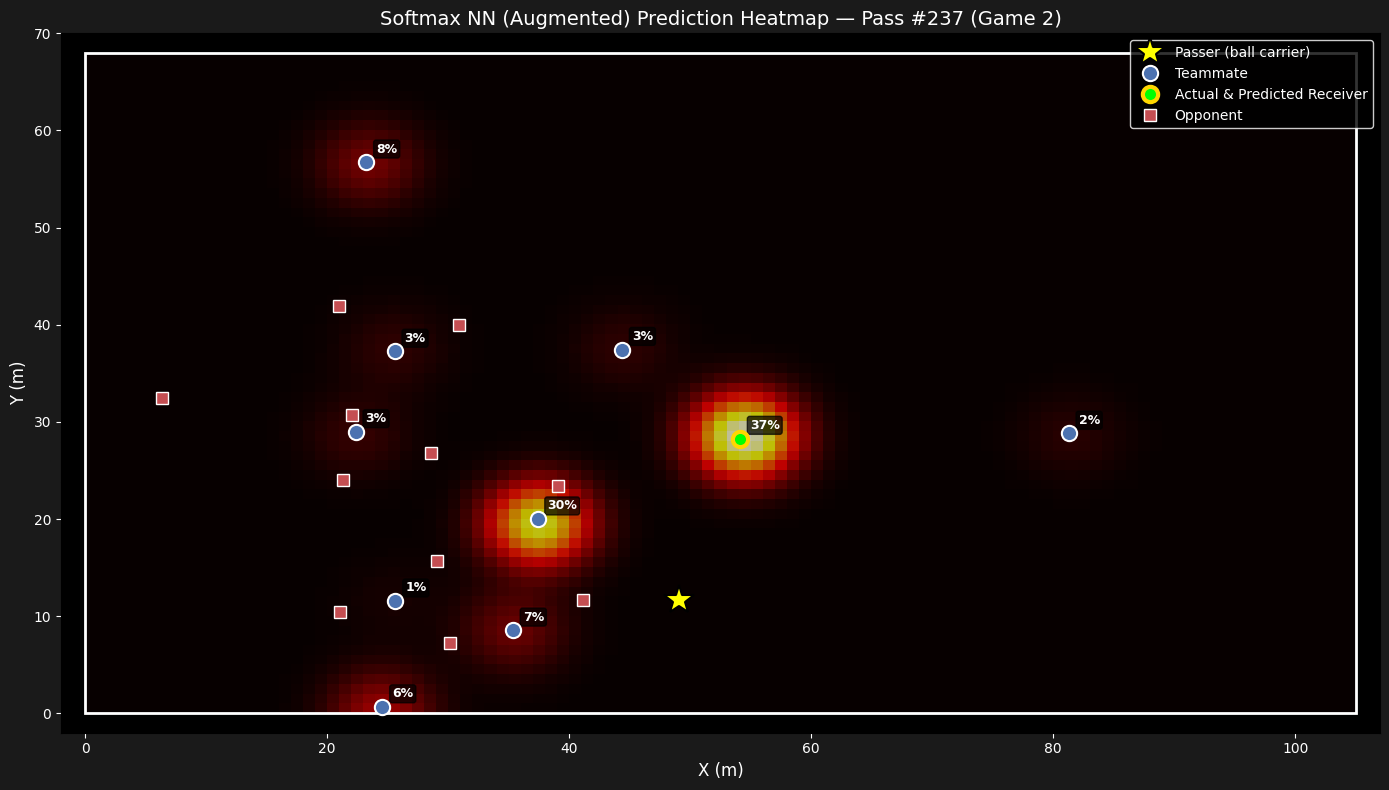

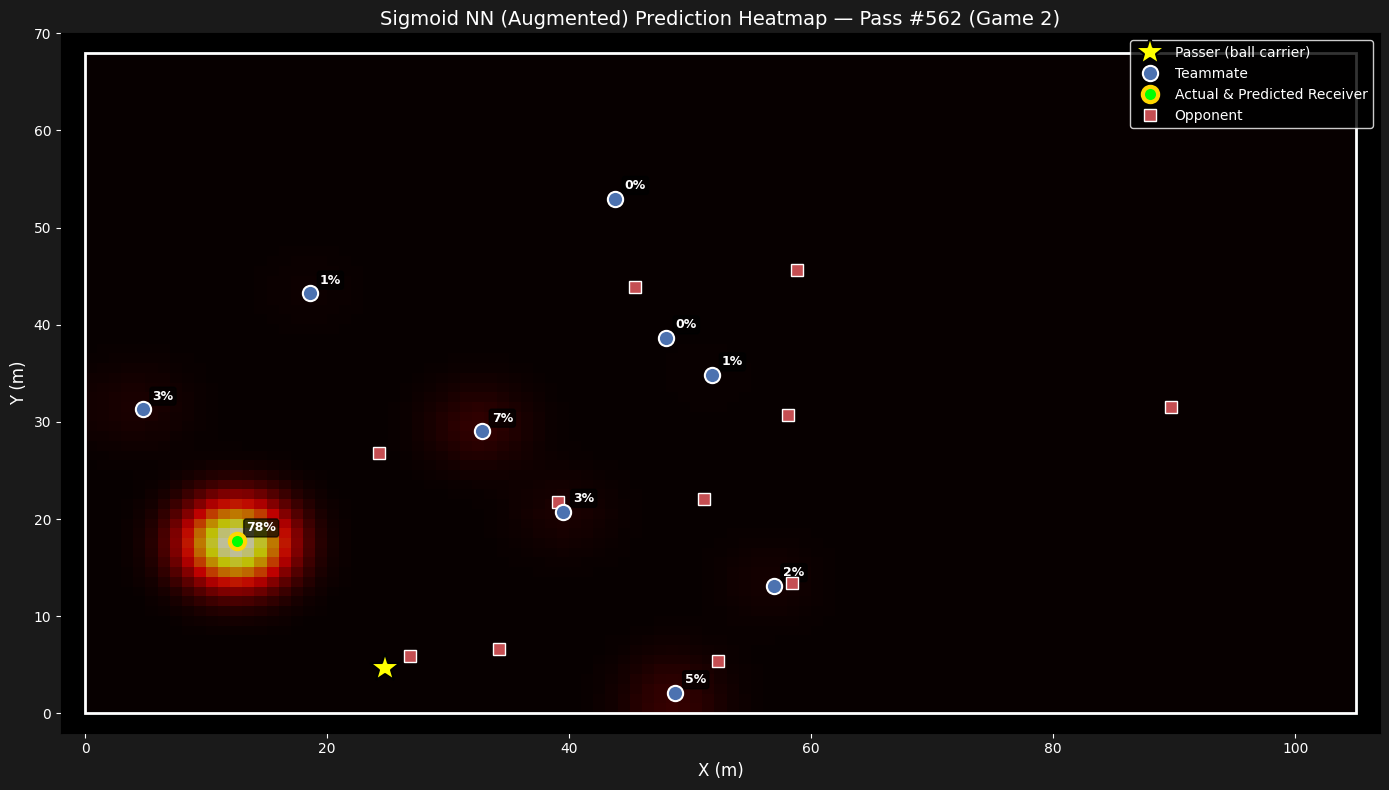

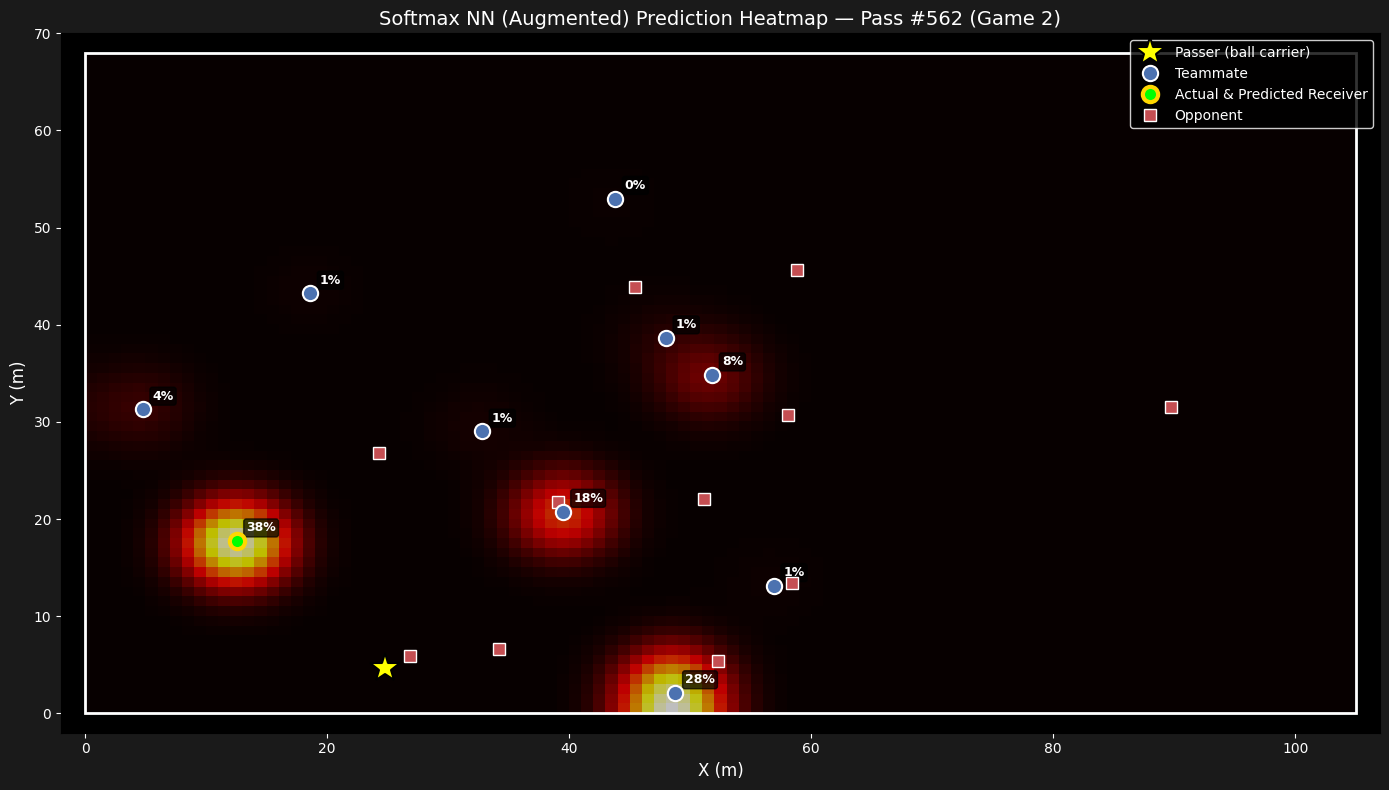

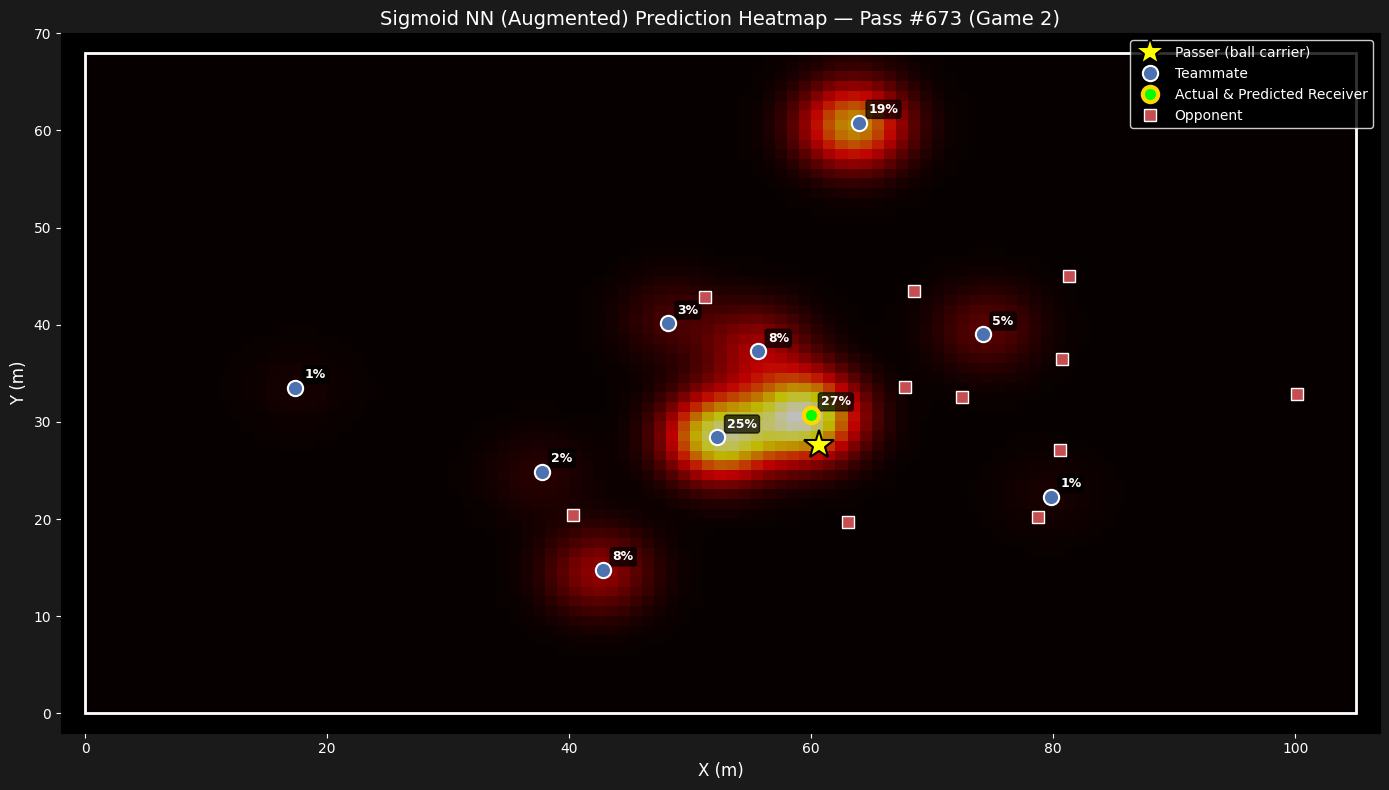

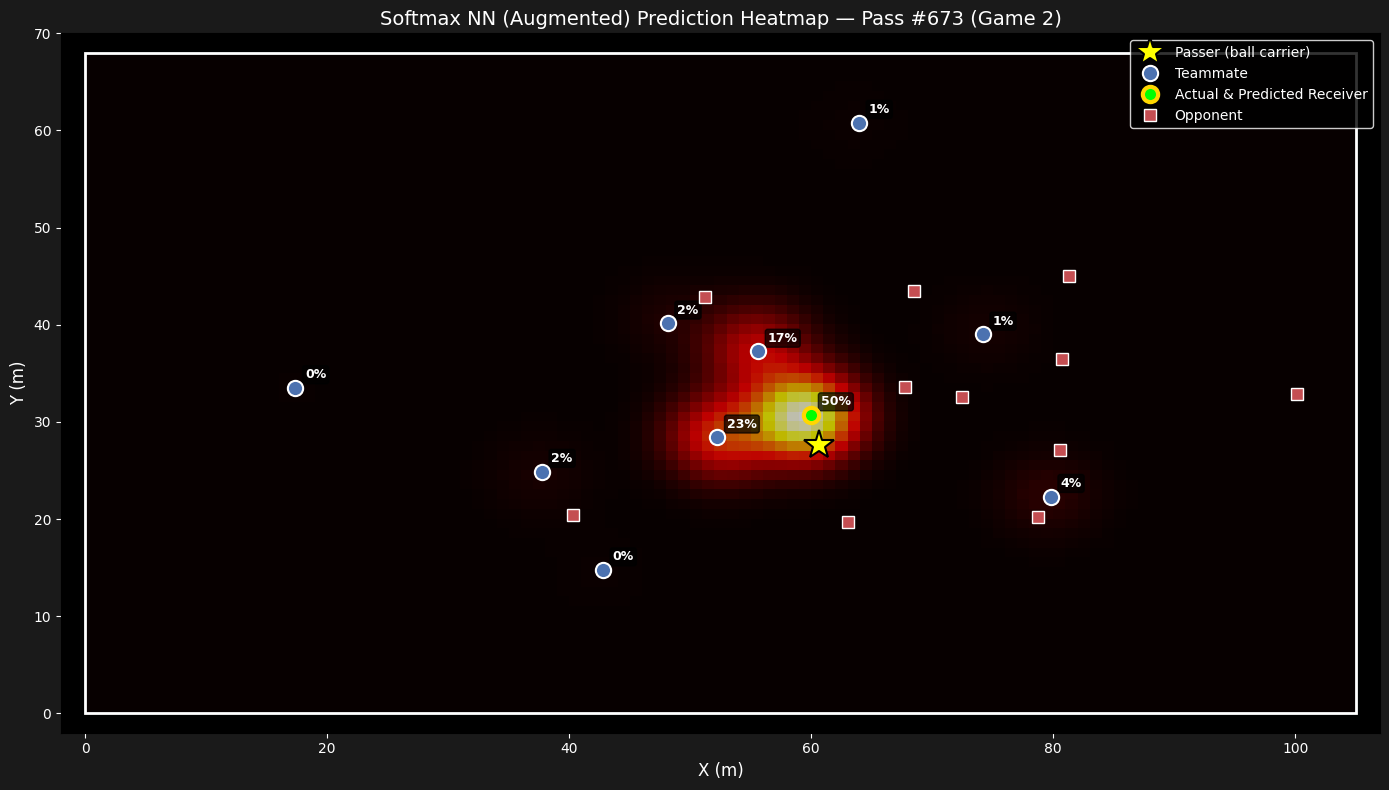

In [ ]:
from scipy.ndimage import gaussian_filter

def plot_prediction_heatmap(sample, probs, model_name='Model', idx=0, sigma=3.0):
    """
    Render predicted pass probabilities as a pitch heatmap.
    Passer = yellow star, Teammates = blue, Opponents = red squares.
    """
    H, W = int(PITCH_WIDTH), int(PITCH_LENGTH)
    heatmap = np.zeros((H, W))

    for i, t in enumerate(sample['teammates']):
        gx = int(np.clip(t['x'], 0, W - 1))
        gy = int(np.clip(t['y'], 0, H - 1))
        heatmap[gy, gx] += probs[i]

    heatmap = gaussian_filter(heatmap, sigma=sigma)

    fig, ax = plt.subplots(figsize=(14, 8))

    ax.imshow(heatmap, origin='lower', cmap='hot', alpha=0.75,
              extent=[0, PITCH_LENGTH, 0, PITCH_WIDTH], aspect='auto')

    ax.add_patch(plt.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH,
                                fill=False, edgecolor='white', linewidth=2))

    # Passer — yellow star, clearly distinct
    ax.plot(sample['passer_x'], sample['passer_y'], '*', color='yellow',
            markersize=22, markeredgecolor='black', markeredgewidth=1.5,
            zorder=6, label='Passer (ball carrier)')

    predicted_idx = np.argmax(probs)
    true_idx = sample['receiver_idx']

    added_labels = set()
    for i, t in enumerate(sample['teammates']):
        if i == true_idx and i == predicted_idx:
            face, edge, lw, lbl = 'lime', 'gold', 3, 'Actual & Predicted Receiver'
        elif i == true_idx:
            face, edge, lw, lbl = 'lime', 'white', 2, 'Actual Receiver'
        elif i == predicted_idx:
            face, edge, lw, lbl = '#4C72B0', 'gold', 3, 'Predicted Receiver'
        else:
            face, edge, lw, lbl = '#4C72B0', 'white', 1.5, 'Teammate'

        label = lbl if lbl not in added_labels else None
        added_labels.add(lbl)
        ax.plot(t['x'], t['y'], 'o', color=face, markersize=11,
                markeredgecolor=edge, markeredgewidth=lw, zorder=4, label=label)
        ax.annotate(f'{probs[i]:.0%}', (t['x'], t['y']),
                    textcoords='offset points', xytext=(7, 7),
                    fontsize=9, color='white', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.7))

    # Opponents — red squares
    for j, o in enumerate(sample['opponents']):
        ax.plot(o['x'], o['y'], 's', color='#C44E52', markersize=8,
                markeredgecolor='white', markeredgewidth=1,
                zorder=3, label='Opponent' if j == 0 else None)

    ax.set_xlim(-2, PITCH_LENGTH + 2)
    ax.set_ylim(-2, PITCH_WIDTH + 2)
    ax.set_xlabel('X (m)', fontsize=12, color='white')
    ax.set_ylabel('Y (m)', fontsize=12, color='white')
    ax.set_title(f'{model_name} Prediction Heatmap — Pass #{idx} (Game {sample["game_id"]})',
                 fontsize=14, color='white')
    ax.set_facecolor('black')
    fig.patch.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')

    ax.legend(fontsize=10, loc='upper right',
              facecolor='black', edgecolor='white', labelcolor='white')

    plt.tight_layout()
    plt.show()


def get_sigmoid_probs(sample, model, scaler):
    """Get per-teammate probabilities from the sigmoid model for a single sample."""
    X_single, _ = build_candidate_features([sample])
    X_scaled = scaler.transform(X_single)
    raw_probs = model(X_scaled, training=False).numpy().flatten()
    # Normalize to a probability distribution
    raw_probs = np.maximum(raw_probs, 1e-8)
    return raw_probs / raw_probs.sum()


def get_softmax_probs(sample, model, scaler):
    """Get per-teammate probabilities from the softmax model for a single sample."""
    X_single, _ = restructure_data([sample])
    X_scaled = scaler.transform(X_single)
    return model(X_scaled, training=False).numpy()[0]


# Pick a few test samples and show both models side by side
np.random.seed(7)
sample_indices = np.random.choice(len(game2_samples), size=3, replace=False)

for si in sample_indices:
    sample = game2_samples[si]

    sig_probs = get_sigmoid_probs(sample, sig_model_aug, scaler_aug)
    plot_prediction_heatmap(sample, sig_probs, model_name='Sigmoid NN (Augmented)', idx=si)

    smax_probs = get_softmax_probs(sample, smax_model_aug, scaler_soft_aug)
    plot_prediction_heatmap(sample, smax_probs, model_name='Softmax NN (Augmented)', idx=si)